<hr>
<div>
<h2>Initialize Environment</h2>
<p>Initializes the shared imports, plotting style, file paths, constants, and helper functions used throughout the study. Each section then loads only the data and defines only the components it requires.</p>
</div>


In [1]:
# Standard Library
from pathlib import Path

# Numerical and Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Optimization
from scipy.optimize import minimize

# Scikit-Learn: Models
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

# Scikit-Learn: Preprocessing and Calibration
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

# Scikit-Learn: Metrics
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    silhouette_score,
)

# Jupyter
from IPython.display import display


In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'
PALETTE = [ACCENT, '#17369b', '#6f8fe8', RED, MUTED, INK]

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRIDLINE,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

# Shared Table Styles
TABLE_STYLES = [
    {
        'selector': 'caption',
        'props': [
            ('caption-side', 'top'),
            ('font-size', '16px'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('padding-bottom', '8px'),
        ],
    },
    {
        'selector': 'th',
        'props': [('text-align', 'left !important')],
    },
    {
        'selector': 'td',
        'props': [('text-align', 'left !important')],
    },
]

In [3]:
# Data Loading and Export Helpers
DATA = Path('data/synthetic')

def load(name):
    
    pq, csv = DATA / f'{name}.parquet', DATA / f'{name}.csv'
    if pq.exists():
        return pd.read_parquet(pq)
    
    if csv.exists():
        return pd.read_csv(csv)
    
    raise FileNotFoundError(
        f'{name} not found in {DATA.resolve()}. Run '
        'data/00_generate_and_validate_data.ipynb, then the earlier sections, first.')

    
def _parquet_available():
    
    for mod in ('pyarrow', 'fastparquet'):
        try:
            __import__(mod)
            return True
        
        except ImportError:
            continue
            
    print('pyarrow/fastparquet not found; writing CSV instead.')
    
    return False


FMT = 'parquet' if _parquet_available() else 'csv'

def save_tables(frames, dest = DATA, with_cols = False):
    
    dest = Path(dest)
    dest.mkdir(parents = True, exist_ok = True)
    
    names, rows, cols = [], [], []
    for name, df in frames.items():
        path = dest / f'{name}.{FMT}'
        df.to_parquet(path, index = False) if FMT == 'parquet' else df.to_csv(path, index = False)
        names.append(path.name)
        rows.append(len(df))
        cols.append(df.shape[1])
        
    data = {'rows': rows, 'cols': cols} if with_cols else {'rows': rows}
    
    return pd.DataFrame(data, index = names).rename_axis(None)


In [4]:
# Domain Constants and Data-Preparation Helpers
CLASSES = ['null', 'partial', 'full']
IDX = {c: i for i, c in enumerate(CLASSES)}
DAY_THRESH = 0.70
PRICE_FIRST, PRICE_ADDL = 10.0, 5.0


def reconstruct_label(df, day_thresh = DAY_THRESH):

    ratio = df['days_bought'] / df['days_traveled']
    lines = df['lines_active'] / df['lines_traveling'].clip(lower = 1)

    y = pd.Series('full', index = df.index, dtype = object)
    y[(ratio < day_thresh) | (lines < 0.999)] = 'partial'
    y[df['days_bought'] == 0] = 'null'

    return y


def build_features(df):

    out = pd.DataFrame(index = df.index)
    out['is_business'] = df['is_business'].astype(int)
    out['lines_on_account'] = df['lines_on_account']
    out['tenure_months'] = df['tenure_months']
    out['premium'] = (df['plan_tier'] == 'premium').astype(int)
    out['value_tier'] = (df['plan_tier'] == 'value').astype(int)
    
    for r in ['asia', 'caribbean', 'central_america', 'europe', 'mideast', 'oceania', 'south_america']:  # Basline: Africa
        out[f'region_{r}'] = (df['region'] == r).astype(int)

    out['month_of_year'] = df['month'] % 12
    out['macro_index'] = df['macro_index']

    return out


def prior_trip_count(df):

    hist = df[['account_id', 'month']].sort_values(['account_id', 'month'])
    cum = hist.groupby('account_id').cumcount()
    same = hist.groupby(['account_id', 'month']).cumcount()

    return (cum - same).reindex(df.index).fillna(0).astype(int)


def load_trips(with_macro = True):

    t = load('trips').merge(load('accounts'), on = 'account_id', how = 'left')

    if with_macro:
        t = t.merge(load('macro')[['month', 'macro_index']], on = 'month', how = 'left')

    return t


In [5]:
# Probability and Price-Shift Helpers
_SORTED_CLASSES = sorted(CLASSES)
_PERM = [CLASSES.index(c) for c in _SORTED_CLASSES]


def LL(y_true, P):
    
    return log_loss(y_true, P[:, _PERM], labels = _SORTED_CLASSES)


def softmax(eta):
    
    e = np.exp(eta - eta.max(axis = 1, keepdims = True))
    
    return e / e.sum(axis=1, keepdims = True)


def logp(p):
    
    return np.log(np.clip(p, 1e-9, 1.0))


def price_shift_logodds(sweep, mult, ref = 1.0):
    
    idx = sweep.index.to_numpy()
    tgt = sweep.iloc[np.argmin(np.abs(idx - mult))][CLASSES].to_numpy()
    base = sweep.iloc[np.argmin(np.abs(idx - ref))][CLASSES].to_numpy()
    
    return logp(tgt) - logp(base)


def apply_price_shift(P0, shift, response_scale = 1.0):
    
    return softmax(logp(P0) + response_scale * shift)


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>04 · Segmentation, Profiling, and Handoff</h1>
<p><strong>Purpose:</strong> Identifies which account groups contribute to the modeled behavioral response and roaming-revenue opportunity, profiles those groups, and publishes the results for downstream exploration.</p>
<p><strong>Context:</strong> This portfolio study evaluates a proposed international roaming price increase across a synthetic book of approximately 50,000 accounts. Notebook 03 estimates the distribution of 12-month roaming-pass revenue across candidate prices. This notebook examines how modeled response and revenue exposure differ across account groups.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Segment on decision-relevant measures, not descriptive customer characteristics.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Accounts are grouped using modeled coverage probabilities, price-response summaries, and historical roaming-pass value.</li>
<li>Characteristics such as business status, tenure, trip frequency, party size, and destination are read back afterward to describe the resulting groups.</li>
<li>Profiling explains the segments; it does not create them.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>The clustering represents several dimensions of the pricing decision.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Baseline probability of choosing no coverage</li>
<li>Magnitude of the modeled price response</li>
<li>Tendency to move toward partial rather than null coverage</li>
<li>Historical roaming-pass value</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Response route and response size are both retained.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Two accounts with similar expected revenue effects may reach that result through different modeled state changes.</li>
<li>One may primarily shift toward null coverage, while another may be more likely to retain partial coverage.</li>
<li>The clustering uses five engineered summaries of these differences rather than the complete probability vector or full price-response curve. The vector is strongly collinear across adjacent prices, and named features (baseline risk, response size, partial-versus-null composition, value) let each segment carry a distinct, explainable pricing or retention treatment. Section 3.1 checks that this representation still recovers the synthetic price-sensitivity factor.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Reduction depth is not a clustering input.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The segments distinguish modeled movement toward partial coverage from movement toward null coverage.</li>
<li>They do not distinguish shallow from deep reductions within the partial-coverage state.</li>
<li>Magnitude Model results enter the subsequent revenue calculations rather than the segment definitions.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Segment descriptions support hypotheses rather than prescribe treatments.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A group with elevated null-state response may motivate a retention-oriented offer.</li>
<li>A group that tends to retain partial coverage may motivate a shorter-duration or more flexible option.</li>
<li>The effectiveness of any intervention would require separate testing.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>One account population, built from the forward-year trip panel.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The synthetic source book contains approximately 50,000 accounts.</li>
<li>The clustering population and the forward-year revenue population are the same 22,328 accounts represented in Notebook 03’s carried-forward trip panel.</li>
<li>Both the clustering inputs and the by-segment revenue attribution are built from the per-trip scenario tables Notebook 03 exports, so segment definitions and segment revenue use one consistent population and one consistent method.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>The resulting segments are descriptive, model-derived groups.</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>They summarize patterns produced by the fitted models and historical value measures.</li>
<li>They are not causal customer types, permanent classifications, or evidence that every account in a segment will respond identically.</li>
</ul></li>
</ol>
<p style="margin-bottom: 0;"><strong>Three Deliverables:</strong></p>
<table style="margin-top: 0; width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Section</th>
<th style="text-align: left;">Output</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Sections 1–4</td>
<td style="text-align: left; vertical-align: top;">Response-and-value segments, including selection, naming, profiling, and stability checks</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Section 5</td>
<td style="text-align: left; vertical-align: top;">Modeled 12-month roaming revenue and revenue exposure by segment</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Section 6</td>
<td style="text-align: left; vertical-align: top;">A Power BI-ready star schema supporting downstream scenario exploration</td>
</tr>
</tbody>
</table>
<p>The exported tables allow business users to explore the study results without rerunning the modeling notebooks. They support a Power BI scenario model but are not themselves a completed operational reporting application.</p>
</div>


In [40]:
# Load Segmentation Inputs
trips = load_trips(with_macro = False)
accounts = load('accounts')
scored = load('scored_trips')
resp = load('account_price_response')
prob_scen = load('sim_prob_scenarios')
rev_scen = load('sim_revenue_scenarios')
sim_sweep = load('simulation_price_sweep')
ground_truth = load('ground_truth')

RESPONSE_RATIO = float(
    load('model_meta').set_index('key')['value'].get('response_ratio', 1.0)
)
DEPTH_BIAS = float(
    load('magnitude_meta').set_index('key')['value'].get('depth_bias', 1.0)
)

# The recommended price is read from Notebook 03's output, not hard-coded here, so a
# rerun that moves the as-fitted optimum flows through to Model 04. The recommendation
# is read from the as-fitted (expected-case) model, not the joint stronger-response
# sensitivity, which is retained elsewhere as a disclosed robustness check.
_fitted_sweep = sim_sweep.loc[sim_sweep['case'].eq('as fitted')]
RECOMMENDED_PRICE = float(
    _fitted_sweep.loc[_fitted_sweep['median'].idxmax(), 'price_multiplier']
)

assert accounts['account_id'].is_unique, (
    'duplicate account IDs in the account table'
)

assert resp['account_id'].is_unique, (
    'duplicate account IDs in the response table'
)

assert set(
    resp['account_id']
).issubset(
    set(accounts['account_id'])
), 'response table contains unmatched account IDs'

probability_grid = np.sort(
    prob_scen[
        'price_multiplier'
    ].round(4).unique()
)

revenue_grid = np.sort(
    rev_scen[
        'price_multiplier'
    ].round(4).unique()
)

assert np.array_equal(
    probability_grid,
    revenue_grid,
), 'probability and revenue scenario grids do not match'

input_manifest = pd.DataFrame({
    'Input': [
        'Trips',
        'Accounts',
        'Scored trips',
        'Account price response',
        'Probability scenarios',
        'Revenue scenarios',
        'Simulation price sweep',
        'Synthetic ground truth',
    ],
    'Rows': [
        len(trips),
        len(accounts),
        len(scored),
        len(resp),
        len(prob_scen),
        len(rev_scen),
        len(sim_sweep),
        len(ground_truth),
    ],
    'Entity Count': [
        trips['trip_id'].nunique(),
        accounts['account_id'].nunique(),
        scored['trip_id'].nunique(),
        resp['account_id'].nunique(),
        prob_scen['trip_id'].nunique(),
        rev_scen['trip_id'].nunique(),
        sim_sweep['price_multiplier'].nunique(),
        ground_truth['account_id'].nunique(),
    ],
    'Entity': [
        'Trips',
        'Accounts',
        'Trips',
        'Accounts',
        'Trips',
        'Trips',
        'Price levels',
        'Accounts',
    ],
    'Purpose': [
        'Trip and customer behavior',
        'Account attributes',
        'Production state probabilities',
        'Segmentation response features',
        'Price-specific state probabilities',
        'Price-specific state revenue',
        'Portfolio simulation results',
        'Synthetic validation only',
    ],
})

display(
    input_manifest.style
    .hide(axis = 'index')
    .format({
        'Rows': '{:,.0f}',
        'Entity Count': '{:,.0f}',
    })
    .set_caption('Customer-Segmentation Input Manifest')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Entity Count'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)


Input,Rows,Entity Count,Entity,Purpose
Trips,"94,579","94,579",Trips,Trip and customer behavior
Accounts,"50,000","50,000",Accounts,Account attributes
Scored trips,"94,579","94,579",Trips,Production state probabilities
Account price response,"29,406","29,406",Accounts,Segmentation response features
Probability scenarios,"2,047,500","52,500",Trips,Price-specific state probabilities
Revenue scenarios,"2,047,500","52,500",Trips,Price-specific state revenue
Simulation price sweep,26,13,Price levels,Portfolio simulation results
Synthetic ground truth,"50,000","50,000",Accounts,Synthetic validation only


<hr>
<div>
<h2>1 · The Clustering Population and Inputs</h2>
<p><strong>Purpose:</strong> Constructs decision-relevant account summaries for clustering using modeled coverage probabilities, modeled price response, and historical roaming-pass value.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The clustering population contains the forward-year accounts with:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Valid modeled probabilities at the standard price and the +20% candidate price</li>
<li>At least one carried-forward trip template used to construct the account summaries</li>
<li>Finite values for every clustering feature</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Five features represent baseline risk, response magnitude, response route, and financial value:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Feature</th>
<th style="text-align: left;">Definition</th>
<th style="text-align: left;">What it captures</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>baseline_risk</code></td>
<td style="text-align: left; vertical-align: top;">Mean <code>P(null)</code> at 1.00</td>
<td style="text-align: left; vertical-align: top;">Modeled walk-away risk at the standard price</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>response_span</code></td>
<td style="text-align: left; vertical-align: top;">Mean <code>P(null)</code> at 1.20 minus mean <code>P(null)</code> at 1.00</td>
<td style="text-align: left; vertical-align: top;">Increase in modeled null-state risk under the proposed price change</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>p_partial_1.20</code></td>
<td style="text-align: left; vertical-align: top;">Mean <code>P(partial)</code> at 1.20</td>
<td style="text-align: left; vertical-align: top;">Modeled tendency to retain partial coverage at the candidate price</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>reduce_vs_quit</code></td>
<td style="text-align: left; vertical-align: top;"><code>p_partial_1.20 / (p_partial_1.20 + p_null_1.20)</code></td>
<td style="text-align: left; vertical-align: top;">Share of modeled non-full coverage that remains partial rather than null at 1.20</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>log_revenue</code></td>
<td style="text-align: left; vertical-align: top;"><code>log1p</code> of historical roaming-pass revenue</td>
<td style="text-align: left; vertical-align: top;">Historical financial value associated with the account</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;">Four features are derived from model outputs. <code>log_revenue</code> is derived from observed historical roaming-pass revenue.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Revenue is included so the segmentation reflects financial materiality as well as behavioral response.</li>
<li>The logarithmic transformation reduces the influence of accounts with unusually high historical revenue.</li>
<li>Revenue remains one clustering dimension; it does not automatically override the response measures.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">All probability features are evaluated at fixed candidate prices.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>This makes accounts comparable even though their historical trips occurred under different observed prices.</li>
<li><code>response_span</code> begins at the standard price rather than 0.90, avoiding dependence on prices below the observed range.</li>
<li><code>p_partial_1.20</code> and <code>p_null_1.20</code> are evaluated at the same price before <code>reduce_vs_quit</code> is calculated.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><code>reduce_vs_quit</code> is interpreted as a modeled probability composition.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A higher value means partial coverage represents a larger share of the account’s modeled non-full probability at 1.20.</li>
<li>A lower value means null coverage represents a larger share.</li>
<li>It does not show that an account repeatedly reduced coverage or establish how an individual account transitions between states.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Magnitude Model reduction depth is not a clustering input.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The features distinguish modeled partial coverage from null coverage.</li>
<li>They do not distinguish shallow from deep reductions within the partial state.</li>
<li>Reduction depth enters the later segment-level revenue calculations.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Account-level probabilities are trip-level predictions averaged within each account.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Panel-trip count is retained as a reliability diagnostic, not a clustering feature.</li>
<li>Section 3.1 recomputes the silhouette on accounts restricted to a minimum panel-trip count to check that single-trip accounts are not driving the structure.</li>
<li>No minimum-history rule is imposed; the stability results in Section 3.1 did not require one.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Features are standardized before K-means clustering.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Each feature has mean zero and unit standard deviation in the clustering population.</li>
<li>Standardization prevents measurement units from controlling Euclidean distance.</li>
<li>It also gives each feature equal nominal influence, so correlated features can unintentionally weight one response dimension more heavily; correlation is checked in note 9.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Correlation is treated as a redundancy diagnostic.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>baseline_risk</code> and <code>reduce_vs_quit</code> correlate at −0.93 because both are built from the null-state probability. <code>reduce_vs_quit</code> is retained because it also carries the partial-versus-null composition that <code>baseline_risk</code> alone does not.</li>
<li>A pair is dropped only when its absolute correlation exceeds 0.95; no pair does.</li>
<li>A formal feature-ablation search is out of scope for this portfolio study.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Input validation confirms that probabilities are finite and in [0, 1], <code>reduce_vs_quit</code> is finite and in [0, 1], <code>response_span</code> is non-negative within numerical tolerance, no account appears twice, and no feature is missing.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The clustering population contains 22,328 forward-year accounts, of which 52.1% are represented by a single carried-forward trip template.</li>
<li>Feature distributions after evaluating the probabilities at fixed prices:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Feature</th>
<th style="text-align: left;">Mean</th>
<th style="text-align: left;">Standard deviation</th>
<th style="text-align: left;">Minimum</th>
<th style="text-align: left;">Median</th>
<th style="text-align: left;">Maximum</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>baseline_risk</code></td>
<td style="text-align: left; vertical-align: top;">0.110</td>
<td style="text-align: left; vertical-align: top;">0.028</td>
<td style="text-align: left; vertical-align: top;">0.063</td>
<td style="text-align: left; vertical-align: top;">0.119</td>
<td style="text-align: left; vertical-align: top;">0.300</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>response_span</code></td>
<td style="text-align: left; vertical-align: top;">0.033</td>
<td style="text-align: left; vertical-align: top;">0.037</td>
<td style="text-align: left; vertical-align: top;">−0.001</td>
<td style="text-align: left; vertical-align: top;">0.025</td>
<td style="text-align: left; vertical-align: top;">0.326</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>p_partial_1.20</code></td>
<td style="text-align: left; vertical-align: top;">0.118</td>
<td style="text-align: left; vertical-align: top;">0.007</td>
<td style="text-align: left; vertical-align: top;">0.084</td>
<td style="text-align: left; vertical-align: top;">0.120</td>
<td style="text-align: left; vertical-align: top;">0.177</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>reduce_vs_quit</code></td>
<td style="text-align: left; vertical-align: top;">0.469</td>
<td style="text-align: left; vertical-align: top;">0.088</td>
<td style="text-align: left; vertical-align: top;">0.182</td>
<td style="text-align: left; vertical-align: top;">0.454</td>
<td style="text-align: left; vertical-align: top;">0.631</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>log_revenue</code></td>
<td style="text-align: left; vertical-align: top;">4.741</td>
<td style="text-align: left; vertical-align: top;">1.359</td>
<td style="text-align: left; vertical-align: top;">0.000</td>
<td style="text-align: left; vertical-align: top;">4.949</td>
<td style="text-align: left; vertical-align: top;">8.654</td>
</tr>
</tbody>
</table></li>
<li>The strongest feature correlations are <code>baseline_risk</code> with <code>reduce_vs_quit</code> (−0.93), <code>response_span</code> with <code>reduce_vs_quit</code> (−0.76), and <code>baseline_risk</code> with <code>response_span</code> (+0.58). No pair exceeds 0.95 in absolute value.</li>
<li>Single-trip accounts are 52.1% of the population. Split-half assignment agreement (Section 3.1) is 0.99 adjusted Rand index, and the silhouette is stable when the population is restricted to accounts with at least 3 or at least 5 panel trips, so single-trip accounts are not treated separately.</li>
<li>The five-feature set is retained: no pair exceeds the 0.95 redundancy threshold, and each feature carries a distinct part of the decision (baseline risk, response size, partial-state level, partial-versus-null composition, and financial value).</li>
<li>Six accounts have a marginally negative <code>response_span</code> (minimum −0.0006), all within numerical tolerance; none are clipped.</li>
</ol>
</div>


In [41]:
# Build Clustering Features
base_probabilities = (
    prob_scen.loc[
        prob_scen[
            'response_scenario'
        ].eq('base')
    ]
    .merge(
        trips[[
            'trip_id',
            'account_id',
        ]],
        on = 'trip_id',
        how = 'inner',
        validate = 'many_to_one',
    )
)

base_probabilities['price_multiplier'] = (
    base_probabilities[
        'price_multiplier'
    ].round(4)
)

required_prices = {
    1.0,
    1.2,
}

available_prices = set(
    base_probabilities[
        'price_multiplier'
    ].unique()
)

assert required_prices.issubset(
    available_prices
), 'required clustering prices are unavailable'

account_probabilities = (
    base_probabilities.loc[
        base_probabilities[
            'price_multiplier'
        ].isin(required_prices)
    ]
    .pivot_table(
        index = 'account_id',
        columns = 'price_multiplier',
        values = [
            'p_null',
            'p_partial',
        ],
        aggfunc = 'mean',
    )
)

p_null_100 = account_probabilities[
    ('p_null', 1.0)
]

p_null_120 = account_probabilities[
    ('p_null', 1.2)
]

p_partial_120 = account_probabilities[
    ('p_partial', 1.2)
]

historical_revenue = (
    trips
    .groupby('account_id')[
        'pass_revenue'
    ]
    .sum()
)

historical_trips = (
    trips
    .groupby('account_id')
    .size()
)

panel_trips = (
    base_probabilities
    .groupby('account_id')[
        'trip_id'
    ]
    .nunique()
)

seg = pd.DataFrame({
    'baseline_risk': p_null_100,
    'response_span':
        p_null_120 - p_null_100,
    'p_partial_120': p_partial_120,
    'reduce_vs_quit': (
        p_partial_120
        / (
            p_partial_120
            + p_null_120
            + 1e-9
        )
    ),
})

seg = (
    seg
    .join(
        historical_revenue.rename(
            'revenue'
        )
    )
    .join(
        historical_trips.rename(
            'trips'
        )
    )
    .join(
        panel_trips.rename(
            'panel_trips'
        )
    )
)

seg['revenue'] = (
    seg['revenue']
    .fillna(0.0)
)

seg['log_revenue'] = np.log1p(
    seg['revenue']
)

seg = seg.reset_index()

FEATS = [
    'baseline_risk',
    'response_span',
    'p_partial_120',
    'reduce_vs_quit',
    'log_revenue',
]

seg = (
    seg
    .dropna(subset = FEATS)
    .reset_index(drop = True)
)

assert np.isfinite(
    seg[FEATS].to_numpy()
).all(), 'non-finite clustering features'

FEATURE_LABELS = {
    'baseline_risk': 'Baseline Risk',
    'response_span': 'Response Span',
    'p_partial_120': 'Partial Probability at 1.20',
    'reduce_vs_quit': 'Reduce vs. Quit',
    'log_revenue': 'Log Revenue',
}

population_summary = pd.DataFrame({
    'Measure': [
        'Clustering accounts',
        'Median panel trips per account',
        'Mean panel trips per account',
        'Accounts in response table',
        'Clustering-population retention',
    ],
    'Value': [
        f'{len(seg):,}',
        f"{seg['panel_trips'].median():.0f}",
        f"{seg['panel_trips'].mean():.1f}",
        f'{len(resp):,}',
        f'{len(seg) / max(len(resp), 1):.1%}',
    ],
})

display(
    population_summary.style
    .hide(axis = 'index')
    .set_caption('Clustering-Population Summary')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

feature_summary = (
    seg[FEATS]
    .describe(
        percentiles = [
            0.10,
            0.50,
            0.90,
        ]
    )
    .T[[
        'mean',
        'std',
        'min',
        '10%',
        '50%',
        '90%',
        'max',
    ]]
    .rename_axis('Feature')
    .reset_index()
    .rename(columns = {
        'mean': 'Mean',
        'std': 'Standard Deviation',
        'min': 'Minimum',
        '10%': '10th Percentile',
        '50%': 'Median',
        '90%': '90th Percentile',
        'max': 'Maximum',
    })
)

feature_summary['Feature'] = (
    feature_summary['Feature']
    .map(FEATURE_LABELS)
)

display(
    feature_summary.style
    .hide(axis = 'index')
    .format({
        'Mean': '{:.3f}',
        'Standard Deviation': '{:.3f}',
        'Minimum': '{:.3f}',
        '10th Percentile': '{:.3f}',
        'Median': '{:.3f}',
        '90th Percentile': '{:.3f}',
        'Maximum': '{:.3f}',
    })
    .set_caption('Clustering-Feature Distribution')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

correlation = (
    seg[FEATS]
    .corr()
)

correlation_display = (
    correlation
    .rename(
        index = FEATURE_LABELS,
        columns = FEATURE_LABELS,
    )
)

display(
    correlation_display.style
    .format('{:.2f}')
    .background_gradient(
        cmap = 'RdBu_r',
        vmin = -1,
        vmax = 1,
        axis = None,
    )
    .set_caption('Clustering-Feature Correlations')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles(TABLE_STYLES)
)

CORRELATION_THRESHOLD = 0.95

high_correlation_pairs = [
    (
        FEATURE_LABELS[first],
        FEATURE_LABELS[second],
        correlation.loc[
            first,
            second,
        ],
    )
    for i, first in enumerate(FEATS)
    for second in FEATS[i + 1:]
    if abs(
        correlation.loc[
            first,
            second,
        ]
    ) > CORRELATION_THRESHOLD
]

correlation_audit = pd.DataFrame({
    'Validation': [
        'Highly correlated feature pairs'
    ],
    'Threshold': [
        CORRELATION_THRESHOLD
    ],
    'Pairs Found': [
        len(high_correlation_pairs)
    ],
    'Status': [
        (
            'Pass'
            if not high_correlation_pairs
            else 'Review'
        )
    ],
    'Detail': [
        (
            'None'
            if not high_correlation_pairs
            else '; '.join(
                f'{first} / {second}: {value:.3f}'
                for first, second, value
                in high_correlation_pairs
            )
        )
    ],
})

display(
    correlation_audit.style
    .hide(axis = 'index')
    .format({
        'Threshold': '{:.2f}',
        'Pairs Found': '{:,.0f}',
    })
    .set_caption('Feature-Redundancy Check')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Measure,Value
Clustering accounts,"22,328"
Median panel trips per account,1
Mean panel trips per account,2.4
Accounts in response table,"29,406"
Clustering-population retention,75.9%


Feature,Mean,Standard Deviation,Minimum,10th Percentile,Median,90th Percentile,Maximum
Baseline Risk,0.110,0.028,0.063,0.072,0.119,0.147,0.300
Response Span,0.033,0.037,-0.001,0.009,0.025,0.067,0.326
Partial Probability at 1.20,0.118,0.007,0.084,0.109,0.120,0.123,0.177
Reduce vs. Quit,0.469,0.088,0.182,0.355,0.454,0.595,0.631
Log Revenue,4.741,1.359,0.000,3.434,4.949,6.111,8.654


,Baseline Risk,Response Span,Partial Probability at 1.20,Reduce vs. Quit,Log Revenue
Baseline Risk,1.00,0.58,-0.10,-0.93,-0.17
Response Span,0.58,1.00,-0.02,-0.76,-0.06
Partial Probability at 1.20,-0.10,-0.02,1.00,0.24,-0.01
Reduce vs. Quit,-0.93,-0.76,0.24,1.00,0.15
Log Revenue,-0.17,-0.06,-0.01,0.15,1.00


Validation,Threshold,Pairs Found,Status,Detail
Highly correlated feature pairs,0.95,0,Pass,None


<hr>
<div>
<h2>2 · How Many Segments?</h2>
<p><strong>Purpose:</strong> Selects the number of account segments by balancing statistical separation, assignment stability, and decision relevance.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">K-means models are compared for <code>k = 2</code> through <code>k = 8</code>.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The clustering features are standardized before fitting.</li>
<li>Each candidate is fitted on the full clustering population with multiple centroid initializations and a fixed random seed.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Statistical separation is evaluated using silhouette score.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Silhouette measures how closely an account resembles its assigned cluster relative to neighboring clusters.</li>
<li>Higher values indicate stronger relative cohesion and separation; they do not prove the segments are permanent or naturally occurring customer types.</li>
<li>The score is estimated on a reproducible sample of 8,000 accounts because the full-population calculation is expensive.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Inertia is a secondary diagnostic.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Inertia necessarily declines as clusters are added.</li>
<li>Its shape can show diminishing improvement but does not by itself set the number of segments.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The selection rule is fixed before the table is read: take <code>k = 5</code> for the extra granularity unless its silhouette is more than 5% below the <code>k = 4</code> value, in which case take <code>k = 4</code>.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Four to five segments is the realistic range for distinct pricing or retention treatment.</li>
<li>Operational usefulness does not override inadequate separation or unstable assignments (checked in Section 3.1).</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Selecting five segments does not imply five prices. The recommended price can stay common across the book while the segment results show where modeled response and revenue exposure are concentrated.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Silhouette is maximized at <code>k = 5</code> (0.416); inertia bends around <code>k = 3</code>–<code>5</code>.
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Candidate</th>
<th style="text-align: left;">Silhouette</th>
<th style="text-align: left;">Relative to best</th>
<th style="text-align: left;">Smallest segment</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>k = 4</code></td>
<td style="text-align: left; vertical-align: top;">0.389</td>
<td style="text-align: left; vertical-align: top;">6.5% below</td>
<td style="text-align: left; vertical-align: top;">2.6%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>k = 5</code></td>
<td style="text-align: left; vertical-align: top;">0.416</td>
<td style="text-align: left; vertical-align: top;">best</td>
<td style="text-align: left; vertical-align: top;">2.6%</td>
</tr>
</tbody>
</table></li>
<li>The selection rule keeps <code>k = 5</code> (0.416 is above 95% of the <code>k = 4</code> value); here <code>k = 5</code> is also the unconstrained silhouette maximum.</li>
<li>The smallest <code>k = 5</code> segment holds 576 accounts (2.6% of 22,328): small, but large enough to carry a distinct treatment, and the naming step sets the near-zero-revenue group aside regardless.</li>
<li>The final segment count is <strong>5</strong>.</li>
</ol>
</div>


Segments,Inertia,Silhouette,Smallest Segment Share
2,"76,042",0.332,41.2%
3,"55,820",0.369,9.7%
4,"45,908",0.389,2.6%
5,"36,489",0.416,2.6%
6,"32,414",0.384,2.6%
7,"29,119",0.292,2.5%
8,"26,542",0.295,2.5%


Measure,Value,Context
Highest-silhouette solution,5,Pure statistical separation
Highest silhouette,0.416,Maximum across evaluated candidates
Four-segment silhouette,0.389,Operational candidate
Five-segment silhouette,0.416,More granular operational candidate
Five vs. four retention,107.0%,Must retain at least 95%
Selected segment count,5,Prespecified operational rule


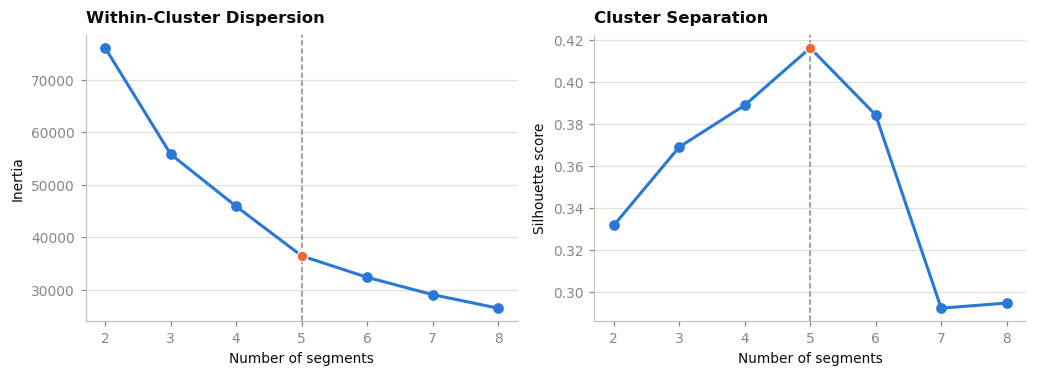

In [42]:
# Choose Segment Count
cluster_scaler = StandardScaler()

Z = cluster_scaler.fit_transform(
    seg[FEATS]
)

silhouette_sample = (
    np.random.default_rng(0)
    .choice(
        len(Z),
        size = min(
            8000,
            len(Z),
        ),
        replace = False,
    )
)

segment_count_rows = []

for candidate_k in range(2, 9):
    candidate_model = KMeans(
        n_clusters = candidate_k,
        n_init = 10,
        random_state = 0,
    ).fit(Z)

    segment_shares = (
        pd.Series(
            candidate_model.labels_
        )
        .value_counts(
            normalize = True
        )
    )

    segment_count_rows.append({
        'Segments': candidate_k,
        'Inertia': candidate_model.inertia_,
        'Silhouette': silhouette_score(
            Z[silhouette_sample],
            candidate_model.labels_[
                silhouette_sample
            ],
        ),
        'Smallest Segment Share':
            segment_shares.min(),
    })

k_tbl = (
    pd.DataFrame(segment_count_rows)
    .set_index('Segments')
)

SILHOUETTE_RETENTION = 0.95

K = (
    5
    if (
        k_tbl.loc[5, 'Silhouette']
        >=  SILHOUETTE_RETENTION
        * k_tbl.loc[4, 'Silhouette']
    )
    else 4
)

best_k = int(
    k_tbl['Silhouette'].idxmax()
)

display(
    k_tbl.reset_index().style
    .hide(axis = 'index')
    .format({
        'Segments': '{:,.0f}',
        'Inertia': '{:,.0f}',
        'Silhouette': '{:.3f}',
        'Smallest Segment Share': '{:.1%}',
    })
    .bar(
        subset = ['Silhouette'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = k_tbl['Silhouette'].max()
        * 1.10,
    )
    .bar(
        subset = ['Smallest Segment Share'],
        color = 'rgba(235, 104, 52, 0.45)',
        vmin = 0,
        vmax = 0.50,
    )
    .set_caption('Candidate Segment-Count Diagnostics')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

selection_summary = pd.DataFrame({
    'Measure': [
        'Highest-silhouette solution',
        'Highest silhouette',
        'Four-segment silhouette',
        'Five-segment silhouette',
        'Five vs. four retention',
        'Selected segment count',
    ],
    'Value': [
        f'{best_k}',
        f"{k_tbl.loc[best_k, 'Silhouette']:.3f}",
        f"{k_tbl.loc[4, 'Silhouette']:.3f}",
        f"{k_tbl.loc[5, 'Silhouette']:.3f}",
        (
            f"{k_tbl.loc[5, 'Silhouette'] / k_tbl.loc[4, 'Silhouette']:.1%}"
        ),
        f'{K}',
    ],
    'Context': [
        'Pure statistical separation',
        'Maximum across evaluated candidates',
        'Operational candidate',
        'More granular operational candidate',
        (
            f'Must retain at least '
            f'{SILHOUETTE_RETENTION:.0%}'
        ),
        'Prespecified operational rule',
    ],
})

display(
    selection_summary.style
    .hide(axis = 'index')
    .set_caption('Segment-Count Selection')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

km = KMeans(
    n_clusters = K,
    n_init = 20,
    random_state = 0,
).fit(Z)

seg['cluster'] = km.labels_

fig, axes = plt.subplots(
    1,
    2,
    figsize = (9.5, 3.5),
)

axes[0].plot(
    k_tbl.index,
    k_tbl['Inertia'],
    marker = 'o',
    color = ACCENT,
    linewidth = 2,
)

axes[0].scatter(
    K,
    k_tbl.loc[K, 'Inertia'],
    color = ACCENT2,
    edgecolor = SURFACE,
    linewidth = 0.8,
    s = 48,
    zorder = 3,
)

axes[0].axvline(
    K,
    color = MUTED,
    linestyle = '--',
    linewidth = 1,
)

axes[0].set(
    xlabel = 'Number of segments',
    ylabel = 'Inertia',
)

axes[0].set_title(
    'Within-Cluster Dispersion',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

axes[0].grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

axes[1].plot(
    k_tbl.index,
    k_tbl['Silhouette'],
    marker = 'o',
    color = ACCENT,
    linewidth = 2,
)

axes[1].scatter(
    K,
    k_tbl.loc[K, 'Silhouette'],
    color = ACCENT2,
    edgecolor = SURFACE,
    linewidth = 0.8,
    s = 48,
    zorder = 3,
)

axes[1].axvline(
    K,
    color = MUTED,
    linestyle = '--',
    linewidth = 1,
)

axes[1].set(
    xlabel = 'Number of segments',
    ylabel = 'Silhouette score',
)

axes[1].set_title(
    'Cluster Separation',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

axes[1].grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

for ax in axes:
    ax.set_xticks(
        k_tbl.index
    )

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>3 · Profiling and Naming the Segments</h2>
<p><strong>Purpose:</strong> Describes the response-and-value clusters using model-derived measures, historical value, and post-clustering account characteristics, then assigns reproducible business-facing names.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The clusters are created in response-and-value space.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>baseline_risk</code>, <code>response_span</code>, the partial-state measures, and <code>log_revenue</code> determine the assignments.</li>
<li>These clustering inputs are reported again during profiling so the differences that created the groups stay visible.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Customer and trip characteristics are added after clustering: business status, trips per account, average trip length, average traveling-party size, tenure, and dominant destination region. They describe the groups but do not enter K-means. Some may still be reflected indirectly because they fed the models that generated the response features.</li>
<li style="margin-bottom: 0.7em;"><code>substitute_ease</code> is a synthetic diagnostic only. It is not an operationally observable targeting field and does not enter the clustering or the Power BI account assignment.</li>
<li style="margin-bottom: 0.7em;">Segment names are assigned by documented, programmatic rules. The taxonomy, thresholds, and wording are study design choices, not names discovered by K-means. Names describe relative differences between clusters, not external business thresholds.</li>
<li style="margin-bottom: 0.7em;">The naming rules use response magnitude, response composition, and historical value:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><strong>Dormant: Travels, Does Not Purchase.</strong> Carries less than 0.5% of historical roaming-pass revenue.</li>
<li><strong>Anchor: High Value, Low Sensitivity.</strong> Lower modeled response span and higher revenue per account than the other clusters.</li>
<li><strong>Steady: barely notices the price.</strong> Low modeled response span without the higher-value condition.</li>
<li><strong>Trimmers: stay but buy less.</strong> High modeled response with a larger partial-state share at 1.20.</li>
<li><strong>Flight Risk: Discontinue Coverage.</strong> High modeled null-state response with a smaller partial-state share.</li>
<li><strong>Swing: Marginal Price Response.</strong> Clusters that do not meet one of the more specific conditions.</li>
<li>When more than one cluster receives the same base name, a higher-, mid-, or lower-value qualifier distinguishes them.</li>
<li>At <code>k = 5</code> the Steady and Trimmers branches did not bind; two clusters matched the Flight-risk branch and were split by value.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Flight risk</strong> refers to modeled movement toward no roaming-pass coverage. It does not mean the customer is expected to leave the wireless company; wireless churn is outside the scope of this study.</li>
<li style="margin-bottom: 0.7em;"><strong>Dormant</strong> identifies a cluster with negligible historical roaming-pass revenue. It does not mean every account in the cluster has never bought a pass. The group stays visible in the profile but is handled separately in the pricing sections, and potential conversion among these accounts is not estimated here.</li>
<li style="margin-bottom: 0.7em;">Segment profiles report account counts and means; Section 3.1 reports account-level synthetic recovery so a segment label is not read as uniform behavior.</li>
<li style="margin-bottom: 0.7em;">Segment labels are versioned outputs, regenerated when the feature set, value of <code>k</code>, or clustering fit changes. Stable numeric cluster identifiers are preserved separately from the descriptive names.</li>
<li style="margin-bottom: 0.7em;">Profiling supports interpretation and treatment hypotheses; it does not establish causal explanations.</li>
</ol>
<p><strong>Observations:</strong></p>
<p style="margin-bottom: 0;">The five clusters:</p>
<table style="margin-top: 0; width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Segment</th>
<th style="text-align: left;">Accounts</th>
<th style="text-align: left;">Account share</th>
<th style="text-align: left;">Revenue share</th>
<th style="text-align: left;">Revenue per account</th>
<th style="text-align: left;">Baseline null risk</th>
<th style="text-align: left;">Response span</th>
<th style="text-align: left;">Business share</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Swing: Marginal Price Response</td>
<td style="text-align: left; vertical-align: top;">10,781</td>
<td style="text-align: left; vertical-align: top;">48.3%</td>
<td style="text-align: left; vertical-align: top;">42.2%</td>
<td style="text-align: left; vertical-align: top;">&#36;180</td>
<td style="text-align: left; vertical-align: top;">0.123</td>
<td style="text-align: left; vertical-align: top;">0.029</td>
<td style="text-align: left; vertical-align: top;">5.9%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Anchor: High Value, Low Sensitivity</td>
<td style="text-align: left; vertical-align: top;">8,100</td>
<td style="text-align: left; vertical-align: top;">36.3%</td>
<td style="text-align: left; vertical-align: top;">46.7%</td>
<td style="text-align: left; vertical-align: top;">&#36;265</td>
<td style="text-align: left; vertical-align: top;">0.079</td>
<td style="text-align: left; vertical-align: top;">0.015</td>
<td style="text-align: left; vertical-align: top;">93.8%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight Risk (Higher Value): Discontinue Coverage</td>
<td style="text-align: left; vertical-align: top;">1,873</td>
<td style="text-align: left; vertical-align: top;">8.4%</td>
<td style="text-align: left; vertical-align: top;">8.9%</td>
<td style="text-align: left; vertical-align: top;">&#36;219</td>
<td style="text-align: left; vertical-align: top;">0.147</td>
<td style="text-align: left; vertical-align: top;">0.097</td>
<td style="text-align: left; vertical-align: top;">1.2%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Dormant: Travels, Does Not Purchase</td>
<td style="text-align: left; vertical-align: top;">998</td>
<td style="text-align: left; vertical-align: top;">4.5%</td>
<td style="text-align: left; vertical-align: top;">Less than 0.1%</td>
<td style="text-align: left; vertical-align: top;">&#36;2</td>
<td style="text-align: left; vertical-align: top;">0.121</td>
<td style="text-align: left; vertical-align: top;">0.027</td>
<td style="text-align: left; vertical-align: top;">9.7%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight Risk (Mid Value): Discontinue Coverage</td>
<td style="text-align: left; vertical-align: top;">576</td>
<td style="text-align: left; vertical-align: top;">2.6%</td>
<td style="text-align: left; vertical-align: top;">2.2%</td>
<td style="text-align: left; vertical-align: top;">&#36;174</td>
<td style="text-align: left; vertical-align: top;">0.155</td>
<td style="text-align: left; vertical-align: top;">0.185</td>
<td style="text-align: left; vertical-align: top;">0.2%</td>
</tr>
</tbody>
</table>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li>Anchor combines the lowest modeled response span (0.015) with the highest revenue per account (&#36;265) and carries 46.7% of forward-panel pass revenue; 93.8% of its accounts are business accounts.</li>
<li>The two Flight-risk segments have the widest modeled null-state response (0.097 and 0.185). Together they are 11.0% of accounts and 11.1% of revenue.</li>
<li>Swing is the largest segment (48.3% of accounts, 42.2% of revenue): a moderate-response middle distinguished from Anchor mainly by value and business mix.</li>
<li>Dormant holds 998 accounts contributing about 0.04% of pass revenue (&#36;2 per account) and is set aside from Sections 4–5.</li>
<li>Business concentration ranges from 0.2% in Flight risk (mid value) to 93.8% in Anchor. This is descriptive and partly inherited from the State Model, which carries business status and a business-specific price interaction; it is not independent validation.</li>
</ol>
</div>


In [43]:
# Profile Segments
prof = seg.merge(
    accounts[[
        'account_id',
        'is_business',
        'lines_on_account',
        'tenure_months',
        'plan_tier',
    ]],
    on='account_id',
    how='left',
    validate='one_to_one',
)

assert prof[
    [
        'is_business',
        'lines_on_account',
        'tenure_months',
        'plan_tier',
    ]
].notna().all().all(), (
    'clustering population contains unmatched account records'
)


def most_common_value(values):
    modes = values.mode()

    return (
        modes.iat[0]
        if not modes.empty
        else 'n/a'
    )


trip_characteristics = (
    trips
    .groupby('account_id')
    .agg(
        avg_days=('days_traveled', 'mean'),
        avg_party=('lines_traveling', 'mean'),
        top_region=('region', most_common_value),
        avg_ease=('substitute_ease', 'mean'),
    )
    .reset_index()
)

prof = prof.merge(
    trip_characteristics,
    on='account_id',
    how='left',
    validate='one_to_one',
)

summary = (
    prof
    .groupby('cluster')
    .agg(
        accounts=('account_id', 'size'),
        revenue=('revenue', 'sum'),
        rev_per_acct=('revenue', 'mean'),
        trips_per_acct=('trips', 'mean'),
        business=('is_business', 'mean'),
        avg_days=('avg_days', 'mean'),
        avg_party=('avg_party', 'mean'),
        tenure=('tenure_months', 'mean'),
        ease=('avg_ease', 'mean'),
        baseline_risk=('baseline_risk', 'mean'),
        response_span=('response_span', 'mean'),
        reduce_vs_quit=('reduce_vs_quit', 'mean'),
    )
)

summary['rev_share'] = (
    summary['revenue']
    / summary['revenue'].sum()
)

summary['acct_share'] = (
    summary['accounts']
    / summary['accounts'].sum()
)

response_profile = (
    summary[[
        'accounts',
        'acct_share',
        'rev_share',
        'rev_per_acct',
        'baseline_risk',
        'response_span',
        'reduce_vs_quit',
    ]]
    .rename_axis('Cluster')
    .reset_index()
    .rename(columns={
        'accounts': 'Accounts',
        'acct_share': 'Account Share',
        'rev_share': 'Revenue Share',
        'rev_per_acct': 'Revenue per Account',
        'baseline_risk': 'Baseline Risk',
        'response_span': 'Response Span',
        'reduce_vs_quit': 'Reduce vs. Quit',
    })
)

display(
    response_profile.style
    .hide(axis='index')
    .format({
        'Cluster': '{:,.0f}',
        'Accounts': '{:,.0f}',
        'Account Share': '{:.1%}',
        'Revenue Share': '{:.1%}',
        'Revenue per Account': '{:,.0f}',
        'Baseline Risk': '{:.1%}',
        'Response Span': '{:+.1%}',
        'Reduce vs. Quit': '{:.1%}',
    })
    .bar(
        subset=['Account Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=0.50,
    )
    .bar(
        subset=['Revenue Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=0.50,
    )
    .bar(
        subset=['Response Span'],
        color='rgba(235, 104, 52, 0.45)',
        vmin=0,
        vmax=max(
            summary['response_span'].max()
            * 1.10,
            0.01,
        ),
    )
    .set_caption('Segment Value and Price-Response Profiles')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

customer_profile = (
    summary[[
        'business',
        'trips_per_acct',
        'avg_days',
        'avg_party',
        'tenure',
        'ease',
    ]]
    .rename_axis('Cluster')
    .reset_index()
    .rename(columns={
        'business': 'Business Share',
        'trips_per_acct': 'Trips per Account',
        'avg_days': 'Average Trip Days',
        'avg_party': 'Average Traveling Lines',
        'tenure': 'Tenure in Months',
        'ease': 'Substitution Ease',
    })
)

display(
    customer_profile.style
    .hide(axis='index')
    .format({
        'Cluster': '{:,.0f}',
        'Business Share': '{:.1%}',
        'Trips per Account': '{:.1f}',
        'Average Trip Days': '{:.1f}',
        'Average Traveling Lines': '{:.2f}',
        'Tenure in Months': '{:.1f}',
        'Substitution Ease': '{:.2f}',
    })
    .bar(
        subset=['Business Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=1,
    )
    .set_caption('Segment Customer and Travel Characteristics')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

destination_rows = []

for cluster, group in prof.groupby('cluster'):
    region_shares = (
        group['top_region']
        .value_counts(normalize=True)
    )

    primary_region = (
        region_shares.index[0]
        if len(region_shares) >= 1
        else 'n/a'
    )

    primary_share = (
        region_shares.iloc[0]
        if len(region_shares) >= 1
        else np.nan
    )

    secondary_region = (
        region_shares.index[1]
        if len(region_shares) >= 2
        else 'n/a'
    )

    secondary_share = (
        region_shares.iloc[1]
        if len(region_shares) >= 2
        else np.nan
    )

    destination_rows.append({
        'Cluster': cluster,
        'Primary Region':
            primary_region.replace('_', ' ').title(),
        'Primary Share': primary_share,
        'Secondary Region':
            secondary_region.replace('_', ' ').title(),
        'Secondary Share': secondary_share,
    })

destination_profile = pd.DataFrame(
    destination_rows
)

display(
    destination_profile.style
    .hide(axis='index')
    .format({
        'Cluster': '{:,.0f}',
        'Primary Share': '{:.1%}',
        'Secondary Share': '{:.1%}',
    }, na_rep='—')
    .bar(
        subset=['Primary Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=1,
    )
    .bar(
        subset=['Secondary Share'],
        color='rgba(137, 135, 129, 0.45)',
        vmin=0,
        vmax=1,
    )
    .set_caption('Dominant Destination Regions by Segment')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Cluster,Accounts,Account Share,Revenue Share,Revenue per Account,Baseline Risk,Response Span,Reduce vs. Quit
0,"10,781",48.3%,42.2%,180,12.3%,+2.9%,43.8%
1,998,4.5%,0.0%,2,12.1%,+2.7%,44.9%
2,"1,873",8.4%,8.9%,219,14.7%,+9.7%,30.6%
3,"8,100",36.3%,46.7%,265,7.9%,+1.5%,56.2%
4,576,2.6%,2.2%,174,15.5%,+18.5%,29.4%


Cluster,Business Share,Trips per Account,Average Trip Days,Average Traveling Lines,Tenure in Months,Substitution Ease
0,5.9%,2.4,7.1,1.55,74.2,0.63
1,9.7%,1.1,6.3,1.46,72.8,0.65
2,1.2%,3.0,7.2,1.61,64.0,0.74
3,93.8%,6.3,4.4,1.31,74.6,0.62
4,0.2%,2.6,7.2,1.42,69.6,0.75


Cluster,Primary Region,Primary Share,Secondary Region,Secondary Share
0,Asia,24.0%,Europe,23.3%
1,Europe,30.3%,Asia,19.4%
2,Europe,57.9%,Asia,20.7%
3,Europe,33.3%,Caribbean,24.5%
4,Europe,67.0%,Asia,12.7%


In [44]:
# Name Segments
segment_ranks = summary.copy()

segment_ranks['rank_span'] = (
    segment_ranks['response_span']
    .rank(pct=True)
)

segment_ranks['rank_shape'] = (
    segment_ranks['reduce_vs_quit']
    .rank(pct=True)
)

segment_ranks['rank_value'] = (
    segment_ranks['rev_per_acct']
    .rank(pct=True)
)

DORMANT_REV_SHARE = 0.005

segment_ranks['dormant'] = (
    summary['rev_share']
    < DORMANT_REV_SHARE
)


def name_segment(row):
    if row['dormant']:
        return 'Dormant: Travels, Does Not Purchase'

    if (
        row['rank_span'] <= 0.30
        and row['rank_value'] >= 0.60
    ):
        return 'Anchor: High Value, Low Sensitivity'

    if row['rank_span'] <= 0.35:
        return 'Steady: Low Price Sensitivity'

    if (
        row['rank_span'] >= 0.70
        and row['rank_shape'] >= 0.60
    ):
        return 'Trimmers: Retain Less Coverage'

    if row['rank_span'] >= 0.70:
        return 'Flight Risk: Discontinue Coverage'

    return 'Swing: Marginal Price Response'


summary['segment'] = (
    segment_ranks
    .apply(
        name_segment,
        axis=1,
    )
)

summary['is_dormant'] = (
    segment_ranks['dormant']
)

for segment_name, group in summary.groupby(
    'segment'
):
    if len(group) == 1:
        continue

    value_rank = (
        group['rev_per_acct']
        .rank(
            ascending=False,
            method='first',
        )
    )

    qualifiers = {
        1: 'Higher Value',
        2: 'Mid Value',
        3: 'Lower Value',
    }

    for cluster_index in group.index:
        category, separator, description = (
            segment_name.partition(': ')
        )

        qualifier = qualifiers.get(
            int(
                value_rank.loc[
                    cluster_index
                ]
            ),
            'Other',
        )

        summary.loc[
            cluster_index,
            'segment',
        ] = (
            f'{category} ({qualifier})'
            f'{separator}'
            f'{description}'
        )

assert summary['segment'].is_unique, (
    'segment names must be unique'
)

NAMES = summary[
    'segment'
].to_dict()

prof['segment'] = (
    prof['cluster']
    .map(NAMES)
)

seg['segment'] = (
    seg['cluster']
    .map(NAMES)
)

assert prof['segment'].notna().all(), (
    'unmapped segment in profile table'
)

assert seg['segment'].notna().all(), (
    'unmapped segment in clustering table'
)

dormant_segments = summary.loc[
    summary['is_dormant']
]

dormant_summary = pd.DataFrame({
    'Disposition': [
        'Excluded from pricing comparisons'
    ],
    'Segments': [
        len(dormant_segments)
    ],
    'Accounts': [
        dormant_segments[
            'accounts'
        ].sum()
    ],
    'Account Share': [
        dormant_segments[
            'acct_share'
        ].sum()
    ],
    'Revenue Share': [
        dormant_segments[
            'rev_share'
        ].sum()
    ],
    'Business Question': [
        'Pass conversion rather than price response'
    ],
})

display(
    dormant_summary.style
    .hide(axis='index')
    .format({
        'Segments': '{:,.0f}',
        'Accounts': '{:,.0f}',
        'Account Share': '{:.1%}',
        'Revenue Share': '{:.2%}',
    })
    .set_caption('Dormant-Segment Disposition')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

segment_profile = (
    summary[[
        'segment',
        'accounts',
        'acct_share',
        'rev_share',
        'rev_per_acct',
        'baseline_risk',
        'response_span',
        'business',
        'trips_per_acct',
    ]]
    .copy()
    .rename(columns={
        'segment': 'Segment',
        'accounts': 'Accounts',
        'acct_share': 'Account Share',
        'rev_share': 'Revenue Share',
        'rev_per_acct': 'Revenue per Account',
        'baseline_risk': 'Baseline Risk',
        'response_span': 'Response Span',
        'business': 'Business Share',
        'trips_per_acct': 'Trips per Account',
    })
    .sort_values(
        'Revenue Share',
        ascending=False,
    )
)

display(
    segment_profile.style
    .hide(axis='index')
    .format({
        'Accounts': '{:,.0f}',
        'Account Share': '{:.1%}',
        'Revenue Share': '{:.1%}',
        'Revenue per Account': '{:,.0f}',
        'Baseline Risk': '{:.1%}',
        'Response Span': '{:+.1%}',
        'Business Share': '{:.1%}',
        'Trips per Account': '{:.1f}',
    })
    .bar(
        subset=['Account Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=0.50,
    )
    .bar(
        subset=['Revenue Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=0.50,
    )
    .bar(
        subset=['Response Span'],
        color='rgba(235, 104, 52, 0.45)',
        vmin=0,
        vmax=max(
            segment_profile[
                'Response Span'
            ].max()
            * 1.10,
            0.01,
        ),
    )
    .set_caption('Customer-Segment Profiles')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Disposition,Segments,Accounts,Account Share,Revenue Share,Business Question
Excluded from pricing comparisons,1,998,4.5%,0.04%,Pass conversion rather than price response


Segment,Accounts,Account Share,Revenue Share,Revenue per Account,Baseline Risk,Response Span,Business Share,Trips per Account
"Anchor: High Value, Low Sensitivity","8,100",36.3%,46.7%,265,7.9%,+1.5%,93.8%,6.3
Swing: Marginal Price Response,"10,781",48.3%,42.2%,180,12.3%,+2.9%,5.9%,2.4
Flight Risk (Higher Value): Discontinue Coverage,"1,873",8.4%,8.9%,219,14.7%,+9.7%,1.2%,3.0
Flight Risk (Mid Value): Discontinue Coverage,576,2.6%,2.2%,174,15.5%,+18.5%,0.2%,2.6
"Dormant: Travels, Does Not Purchase",998,4.5%,0.0%,2,12.1%,+2.7%,9.7%,1.1


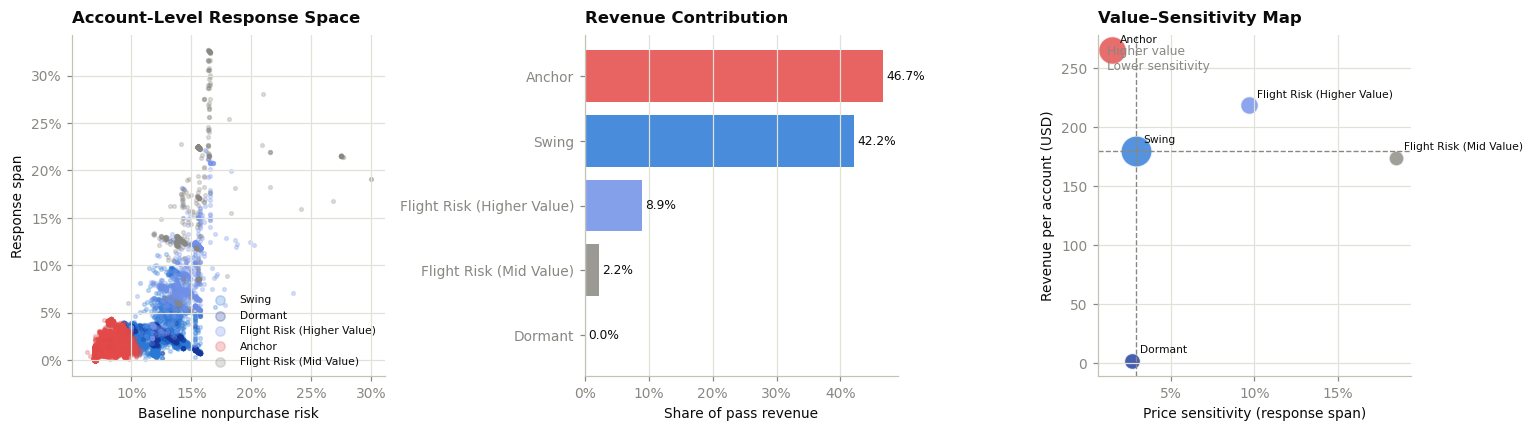

In [45]:
# Plot Segment Profiles
segment_colors = {
    cluster: PALETTE[
        i % len(PALETTE)
    ]
    for i, cluster
    in enumerate(summary.index)
}

short_names = (
    summary['segment']
    .str.split(': ')
    .str[0]
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4),
)

for cluster in summary.index:
    cluster_mask = (
        seg['cluster'] == cluster
    )

    axes[0].scatter(
        seg.loc[
            cluster_mask,
            'baseline_risk',
        ],
        seg.loc[
            cluster_mask,
            'response_span',
        ],
        s=6,
        alpha=0.25,
        color=segment_colors[cluster],
        label=short_names.loc[cluster],
    )

axes[0].set(
    xlabel='Baseline nonpurchase risk',
    ylabel='Response span',
)

axes[0].set_title(
    'Account-Level Response Space',
    loc='left',
    fontweight='bold',
    pad=8,
)

axes[0].xaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[0].yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[0].grid(
    color=GRIDLINE,
    linewidth=0.8,
)

axes[0].legend(
    frameon=False,
    fontsize=7,
    markerscale=2.5,
    loc='best',
)

revenue_order = (
    summary['rev_share']
    .sort_values()
    .index
)

revenue_names = short_names.loc[
    revenue_order
]

revenue_shares = summary.loc[
    revenue_order,
    'rev_share',
]

revenue_colors = [
    segment_colors[cluster]
    for cluster in revenue_order
]

bars = axes[1].barh(
    revenue_names,
    revenue_shares,
    color=revenue_colors,
    alpha=0.85,
)

axes[1].set_xlabel(
    'Share of pass revenue'
)

axes[1].set_title(
    'Revenue Contribution',
    loc='left',
    fontweight='bold',
    pad=8,
)

axes[1].xaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[1].grid(
    axis='x',
    color=GRIDLINE,
    linewidth=0.8,
)

for bar, share in zip(
    bars,
    revenue_shares,
):
    axes[1].text(
        bar.get_width() + 0.005,
        bar.get_y()
        + bar.get_height() / 2,
        f'{share:.1%}',
        va='center',
        fontsize=8,
        color=INK,
    )

bubble_sizes = (
    80
    + 700
    * summary['acct_share']
)

for cluster in summary.index:
    x_value = summary.loc[
        cluster,
        'response_span',
    ]

    y_value = summary.loc[
        cluster,
        'rev_per_acct',
    ]

    axes[2].scatter(
        x_value,
        y_value,
        s=bubble_sizes.loc[cluster],
        color=segment_colors[cluster],
        alpha=0.80,
        edgecolor=SURFACE,
        linewidth=1,
    )

    axes[2].annotate(
        short_names.loc[cluster],
        (
            x_value,
            y_value,
        ),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=7,
    )

median_response = (
    summary['response_span']
    .median()
)

median_value = (
    summary['rev_per_acct']
    .median()
)

axes[2].axvline(
    median_response,
    color=MUTED,
    linestyle='--',
    linewidth=0.9,
)

axes[2].axhline(
    median_value,
    color=MUTED,
    linestyle='--',
    linewidth=0.9,
)

axes[2].annotate(
    'Higher value\nLower sensitivity',
    xy=(0.03, 0.97),
    xycoords='axes fraction',
    ha='left',
    va='top',
    fontsize=8,
    color=MUTED,
)

axes[2].set(
    xlabel='Price sensitivity (response span)',
    ylabel='Revenue per account (USD)',
)

axes[2].set_title(
    'Value–Sensitivity Map',
    loc='left',
    fontweight='bold',
    pad=8,
)

axes[2].xaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

axes[2].yaxis.set_major_formatter(
    lambda value, position: f'{value:,.0f}'
)

axes[2].grid(
    color=GRIDLINE,
    linewidth=0.8,
)

plt.tight_layout()
plt.show()


<div>
<h3>3.1 · Segment Stability and Synthetic Recovery</h3>
<p><strong>Purpose:</strong> Tests whether the feature representation and clustering procedure produce reproducible account assignments, then checks whether the segments preserve information about the known synthetic price-sensitivity factor.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">Stability is evaluated after the features and the number of segments are fixed. Validation uses numeric cluster identifiers, not the business-facing names; names are applied only after the structure passes.</li>
<li style="margin-bottom: 0.7em;">The clustering pipeline is refitted for each resample.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Accounts are randomly split into two halves.</li>
<li>The feature scaler is fitted separately within each half.</li>
<li>K-means is fitted on each half with the selected value of <code>k</code>.</li>
<li>Each half-sample model then assigns the full population using its own scaler and centroids.</li>
<li>The procedure is repeated across 20 random splits.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Agreement between the two full-population labelings is measured with label-invariant metrics.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Adjusted Rand index measures similarity between assignments while accounting for chance.</li>
<li>Adjusted mutual information gives a second, information-based comparison.</li>
<li>Neither requires cluster numbers to match across fits.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">History reliability is checked separately: the silhouette is recomputed on the subset of accounts with at least 1, at least 3, and at least 5 panel trips, to confirm the structure is not an artifact of single-trip accounts.</li>
<li style="margin-bottom: 0.7em;">The reproducibility criterion is a median adjusted Rand index of at least 0.80 across the 20 splits. This is a study-specific decision threshold, not proof that the clusters are naturally occurring customer types.</li>
<li style="margin-bottom: 0.7em;">Synthetic recovery is evaluated separately from stability.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>price_sensitivity</code> and <code>sensitivity_decile</code> are synthetic data-generation fields.</li>
<li>They do not enter feature construction, standardization, clustering, selection of <code>k</code>, or naming, and are joined only after the segmentation is final.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Recovery of the synthetic price-sensitivity factor is assessed with:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Account-level Spearman rank correlation between latent <code>price_sensitivity</code> and modeled <code>response_span</code></li>
<li>Mean latent sensitivity within each segment</li>
<li>The share of latent-sensitivity variance associated with segment membership (eta-squared)</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Because more-negative latent sensitivity means greater price sensitivity, successful directional recovery produces a negative correlation with <code>response_span</code>.</li>
<li style="margin-bottom: 0.7em;">Synthetic recovery has a narrow interpretation: it shows whether the model-derived segmentation retains information about a known factor used to generate this dataset. It does not establish that the same latent segments exist among operational customers.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Split-half agreement over 20 repeats, with separately fitted scalers:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Metric</th>
<th style="text-align: left;">Mean</th>
<th style="text-align: left;">Standard deviation</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Adjusted Rand index</td>
<td style="text-align: left; vertical-align: top;">0.988</td>
<td style="text-align: left; vertical-align: top;">0.005</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Adjusted mutual information</td>
<td style="text-align: left; vertical-align: top;">0.976</td>
<td style="text-align: left; vertical-align: top;">0.007</td>
</tr>
</tbody>
</table></li>
<li>History reliability, silhouette by minimum panel-trip count:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Minimum panel trips</th>
<th style="text-align: left;">Accounts</th>
<th style="text-align: left;">Silhouette</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">≥ 1</td>
<td style="text-align: left; vertical-align: top;">22,328</td>
<td style="text-align: left; vertical-align: top;">0.415</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">≥ 3</td>
<td style="text-align: left; vertical-align: top;">5,906</td>
<td style="text-align: left; vertical-align: top;">0.394</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">≥ 5</td>
<td style="text-align: left; vertical-align: top;">2,490</td>
<td style="text-align: left; vertical-align: top;">0.493</td>
</tr>
</tbody>
</table>
<p>The structure holds; it does not weaken when single-trip accounts are removed.</p></li>
<li>The account-level Spearman correlation between latent <code>price_sensitivity</code> and modeled <code>response_span</code> is −0.520 (negative is the correct direction).</li>
<li>Mean latent sensitivity by segment (less negative = less price-sensitive):
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Segment</th>
<th style="text-align: left;">Mean latent sensitivity</th>
<th style="text-align: left;">Modeled response span</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Flight Risk (Mid Value): Discontinue Coverage</td>
<td style="text-align: left; vertical-align: top;">−1.424</td>
<td style="text-align: left; vertical-align: top;">0.185</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight Risk (Higher Value): Discontinue Coverage</td>
<td style="text-align: left; vertical-align: top;">−1.422</td>
<td style="text-align: left; vertical-align: top;">0.097</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Swing: Marginal Price Response</td>
<td style="text-align: left; vertical-align: top;">−1.403</td>
<td style="text-align: left; vertical-align: top;">0.029</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Dormant: Travels, Does Not Purchase</td>
<td style="text-align: left; vertical-align: top;">−1.396</td>
<td style="text-align: left; vertical-align: top;">0.027</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Anchor: High Value, Low Sensitivity</td>
<td style="text-align: left; vertical-align: top;">−0.568</td>
<td style="text-align: left; vertical-align: top;">0.015</td>
</tr>
</tbody>
</table></li>
<li>Segment membership accounts for 43.2% of the variance in the latent price-sensitivity factor (eta-squared).</li>
<li>The clustering meets the predefined stability criterion (median adjusted Rand index of at least 0.80): it reaches 0.99.</li>
<li>The recovery results support the narrower conclusion that the model-derived features retain information about the synthetic price-sensitivity mechanism: the direction is correct and Anchor separates cleanly, while the four more-sensitive segments differ mainly in the size of the modeled response rather than in the latent factor.</li>
</ol>
</div>


Metric,Mean,Standard Deviation,Minimum,Maximum,Repeats
Adjusted Rand index,0.988,0.005,0.972,0.994,20
Adjusted mutual information,0.976,0.007,0.955,0.986,20


Minimum Panel Trips,Accounts,Population Retained,Silhouette Score
1,"22,328",100.0%,0.415
3,"5,906",26.5%,0.394
5,"2,490",11.2%,0.493


Matched Accounts,Spearman Correlation,Sensitivity Variance Explained,Validation Scope
"22,328",-0.520,43.2%,Synthetic ground truth only


Segment,Accounts,True Sensitivity,Modeled Response Span
Flight Risk (Mid Value): Discontinue Coverage,576,-1.424,18.5%
Flight Risk (Higher Value): Discontinue Coverage,"1,873",-1.422,9.7%
Swing: Marginal Price Response,"10,781",-1.403,2.9%
"Dormant: Travels, Does Not Purchase",998,-1.396,2.7%
"Anchor: High Value, Low Sensitivity","8,100",-0.568,1.5%


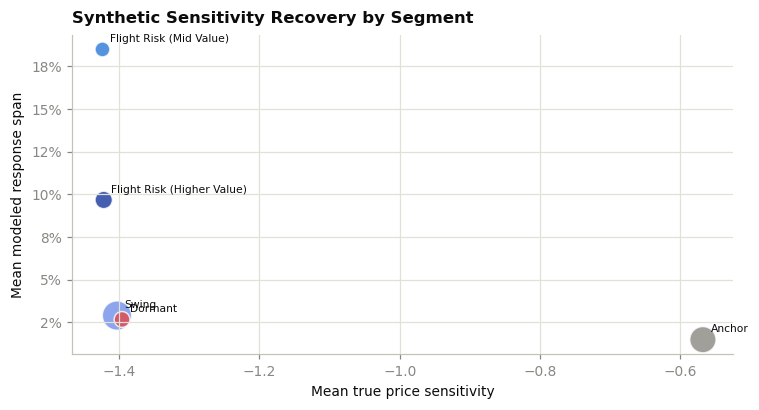

In [46]:
# Validate Segment Stability
X_raw = seg[
    FEATS
].to_numpy()

stability_rng = np.random.default_rng(5)


def assign_to_centers(
    standardized_features,
    centers,
):
    squared_distance = (
        standardized_features[:, None, :]
        - centers[None, :, :]
    ) ** 2

    return (
        squared_distance
        .sum(axis=2)
        .argmin(axis=1)
    )


adjusted_rand = []
adjusted_mutual_info = []

for repeat in range(20):
    first_half = (
        stability_rng.random(
            len(X_raw)
        )
        < 0.5
    )

    second_half = ~first_half

    if (
        first_half.sum() <= K
        or second_half.sum() <= K
    ):
        continue

    first_scaler = StandardScaler().fit(
        X_raw[first_half]
    )

    second_scaler = StandardScaler().fit(
        X_raw[second_half]
    )

    first_model = KMeans(
        n_clusters=K,
        n_init=10,
        random_state=1,
    ).fit(
        first_scaler.transform(
            X_raw[first_half]
        )
    )

    second_model = KMeans(
        n_clusters=K,
        n_init=10,
        random_state=2,
    ).fit(
        second_scaler.transform(
            X_raw[second_half]
        )
    )

    first_labels = assign_to_centers(
        first_scaler.transform(X_raw),
        first_model.cluster_centers_,
    )

    second_labels = assign_to_centers(
        second_scaler.transform(X_raw),
        second_model.cluster_centers_,
    )

    adjusted_rand.append(
        adjusted_rand_score(
            first_labels,
            second_labels,
        )
    )

    adjusted_mutual_info.append(
        adjusted_mutual_info_score(
            first_labels,
            second_labels,
        )
    )

adjusted_rand = np.array(
    adjusted_rand
)

adjusted_mutual_info = np.array(
    adjusted_mutual_info
)

stability_summary = pd.DataFrame({
    'Metric': [
        'Adjusted Rand index',
        'Adjusted mutual information',
    ],
    'Mean': [
        adjusted_rand.mean(),
        adjusted_mutual_info.mean(),
    ],
    'Standard Deviation': [
        adjusted_rand.std(ddof=1),
        adjusted_mutual_info.std(ddof=1),
    ],
    'Minimum': [
        adjusted_rand.min(),
        adjusted_mutual_info.min(),
    ],
    'Maximum': [
        adjusted_rand.max(),
        adjusted_mutual_info.max(),
    ],
    'Repeats': [
        len(adjusted_rand),
        len(adjusted_mutual_info),
    ],
})

display(
    stability_summary.style
    .hide(axis='index')
    .format({
        'Mean': '{:.3f}',
        'Standard Deviation': '{:.3f}',
        'Minimum': '{:.3f}',
        'Maximum': '{:.3f}',
        'Repeats': '{:,.0f}',
    })
    .bar(
        subset=['Mean'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=1,
    )
    .set_caption('Split-Half Cluster Agreement')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

history_rows = []

for minimum_trips in [
    1,
    3,
    5,
]:
    eligible = (
        seg['panel_trips']
        >= minimum_trips
    ).to_numpy()

    silhouette = (
        silhouette_score(
            StandardScaler().fit_transform(
                seg.loc[
                    eligible,
                    FEATS,
                ]
            ),
            seg.loc[
                eligible,
                'cluster',
            ],
        )
        if eligible.sum() > K
        else np.nan
    )

    history_rows.append({
        'Minimum Panel Trips': minimum_trips,
        'Accounts': eligible.sum(),
        'Population Retained':
            eligible.mean(),
        'Silhouette Score': silhouette,
    })

history_reliability = pd.DataFrame(
    history_rows
)

display(
    history_reliability.style
    .hide(axis='index')
    .format({
        'Minimum Panel Trips': '{:,.0f}',
        'Accounts': '{:,.0f}',
        'Population Retained': '{:.1%}',
        'Silhouette Score': '{:.3f}',
    }, na_rep='—')
    .bar(
        subset=['Population Retained'],
        color='rgba(137, 135, 129, 0.45)',
        vmin=0,
        vmax=1,
    )
    .bar(
        subset=['Silhouette Score'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=1,
    )
    .set_caption('History-Reliability Check')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

ground_truth_validation = seg.merge(
    ground_truth[[
        'account_id',
        'price_sensitivity',
    ]],
    on='account_id',
    how='inner',
    validate='one_to_one',
)

account_correlation = (
    ground_truth_validation[
        'price_sensitivity'
    ]
    .corr(
        ground_truth_validation[
            'response_span'
        ],
        method='spearman',
    )
)

grand_mean = (
    ground_truth_validation[
        'price_sensitivity'
    ]
    .mean()
)

total_variation = float(
    (
        ground_truth_validation[
            'price_sensitivity'
        ]
        - grand_mean
    )
    .pow(2)
    .sum()
)

between_segment_variation = float(
    ground_truth_validation
    .groupby('segment')[
        'price_sensitivity'
    ]
    .apply(
        lambda values: (
            len(values)
            * (
                values.mean()
                - grand_mean
            ) ** 2
        )
    )
    .sum()
)

eta_squared = (
    between_segment_variation
    / total_variation
    if total_variation > 0
    else np.nan
)

recovery_summary = pd.DataFrame({
    'Matched Accounts': [
        len(ground_truth_validation)
    ],
    'Spearman Correlation': [
        account_correlation
    ],
    'Sensitivity Variance Explained': [
        eta_squared
    ],
    'Validation Scope': [
        'Synthetic ground truth only'
    ],
})

display(
    recovery_summary.style
    .hide(axis='index')
    .format({
        'Matched Accounts': '{:,.0f}',
        'Spearman Correlation': '{:+.3f}',
        'Sensitivity Variance Explained': '{:.1%}',
    })
    .set_caption('Synthetic Sensitivity-Recovery Summary')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset=[
            'Spearman Correlation',
            'Sensitivity Variance Explained',
        ],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

recovery_by_segment = (
    ground_truth_validation
    .groupby('segment')
    .agg(
        Accounts=('account_id', 'size'),
        True_Sensitivity=(
            'price_sensitivity',
            'mean',
        ),
        Modeled_Response_Span=(
            'response_span',
            'mean',
        ),
    )
    .reset_index()
    .rename(columns={
        'segment': 'Segment',
        'True_Sensitivity': 'True Sensitivity',
        'Modeled_Response_Span':
            'Modeled Response Span',
    })
    .sort_values('True Sensitivity')
)

display(
    recovery_by_segment.style
    .hide(axis='index')
    .format({
        'Accounts': '{:,.0f}',
        'True Sensitivity': '{:+.3f}',
        'Modeled Response Span': '{:.1%}',
    })
    .bar(
        subset=['Modeled Response Span'],
        color='rgba(235, 104, 52, 0.45)',
        vmin=0,
        vmax=max(
            recovery_by_segment[
                'Modeled Response Span'
            ].max()
            * 1.10,
            0.01,
        ),
    )
    .set_caption('Synthetic Sensitivity Recovery by Segment')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

recovery_colors = [
    PALETTE[
        i % len(PALETTE)
    ]
    for i in range(
        len(recovery_by_segment)
    )
]

bubble_sizes = (
    80
    + 600
    * (
        recovery_by_segment['Accounts']
        / recovery_by_segment[
            'Accounts'
        ].sum()
    )
)

fig, ax = plt.subplots(
    figsize=(7, 3.8),
)

ax.scatter(
    recovery_by_segment[
        'True Sensitivity'
    ],
    recovery_by_segment[
        'Modeled Response Span'
    ],
    s=bubble_sizes,
    color=recovery_colors,
    alpha=0.80,
    edgecolor=SURFACE,
    linewidth=1,
)

for _, row in recovery_by_segment.iterrows():
    short_name = row[
        'Segment'
    ].split(': ')[0]

    ax.annotate(
        short_name,
        (
            row['True Sensitivity'],
            row['Modeled Response Span'],
        ),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=7,
    )

ax.set(
    xlabel='Mean true price sensitivity',
    ylabel='Mean modeled response span',
)

ax.set_title(
    'Synthetic Sensitivity Recovery by Segment',
    loc='left',
    fontweight='bold',
    pad=8,
)

ax.yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

ax.grid(
    color=GRIDLINE,
    linewidth=0.8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>4 · Segment-Level Revenue Response</h2>
<p style="border-left: 3px solid #b23c17; padding-left: 0.8em; color: #4A4A4A;"><strong>Note:</strong> This section’s revenue decomposition is deliberately computed under the joint stronger-response sensitivity throughout (see its own design notes below), independent of Section 5’s headline recommendation. Its “Gain at Recommended” column and reference line read RECOMMENDED_PRICE dynamically, so they correctly track the as-fitted recommendation (currently 1.20) even though the curve itself is the more conservative joint-sensitivity case.</p>
<p><strong>Purpose:</strong> Decomposes the company-wide revenue result by segment to show where the modeled benefit and the behavioral exposure of a common price change are concentrated.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The segment curves describe a heterogeneous account population under one company-wide price. They do not assume each segment receives a different price; segment results support revenue attribution, monitoring, and treatment hypotheses.</li>
<li style="margin-bottom: 0.7em;">The calculation uses the same forward-year population and per-trip scenario tables as Notebook 03: 52,500 carried-forward trip templates, each priced account assigned to exactly one of the four active segments. Dormant is excluded here, as it is throughout Sections 4-5: it purchases at no price, so no price answers it.</li>
<li style="margin-bottom: 0.7em;">The decomposition is deterministic, not an in-loop simulation.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>For each trip template and each grid price, expected revenue is <code>p_null · rev_null + p_partial · rev_partial + p_full · rev_full</code>, using the State Model probabilities and the Magnitude Model state revenues at that price.</li>
<li>These per-trip expectations are summed by segment.</li>
<li>There is no trip-occurrence draw, macro path, or market-share draw here; those belong to the Notebook 03 simulation, which this section cross-checks against.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The primary results use the joint stronger-response sensitivity (<code>response_scale = 1.74</code>, <code>depth_scale = 1.04</code>), the conservative robustness case used throughout this decomposition. The base-model curve is also available.</li>
<li style="margin-bottom: 0.7em;">Because the decomposition is deterministic and additive, segment revenues sum to the portfolio curve exactly at every price, and segment gains relative to 1.00 sum to the portfolio gain exactly. Reconciliation is by construction rather than a tolerance check across iterations.</li>
<li style="margin-bottom: 0.7em;">A segment’s highest-revenue grid price is reported descriptively. It is called an optimum only when it sits inside the grid; a result at the 1.20 edge is reported as the highest evaluated price, not a proven optimum.</li>
<li style="margin-bottom: 0.7em;">All results are modeled roaming-pass revenue. They exclude wireless churn, customer-lifetime effects, competitor reactions, reputational effects, and implementation costs.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The decomposition covers 22,328 forward-year accounts and 52,500 trip templates, each mapped to exactly one segment; no unmatched or duplicate records.</li>
<li>Segment revenues sum to the portfolio curve by construction. The deterministic portfolio curve sits about 8% above the Notebook 03 joint-sensitivity simulation median in level (&#36;2.87M versus &#36;2.65M at 1.00) because it is an expected-value track over the priced-segment templates with no occurrence thinning or macro variation, but it turns over at the same price:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Price</th>
<th style="text-align: left;">Deterministic portfolio</th>
<th style="text-align: left;">§03 simulation median (joint sensitivity)</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">1.00</td>
<td style="text-align: left; vertical-align: top;">&#36;2,868,427</td>
<td style="text-align: left; vertical-align: top;">&#36;2,654,285</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">1.15</td>
<td style="text-align: left; vertical-align: top;">&#36;3,026,004</td>
<td style="text-align: left; vertical-align: top;">&#36;2,797,522</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">1.20</td>
<td style="text-align: left; vertical-align: top;">&#36;2,999,900</td>
<td style="text-align: left; vertical-align: top;">&#36;2,769,348</td>
</tr>
</tbody>
</table></li>
<li>Segment contributions under the joint stronger-response sensitivity:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Segment</th>
<th style="text-align: left;">Account share</th>
<th style="text-align: left;">Standard-price revenue share</th>
<th style="text-align: left;">Gain at 1.15 vs 1.00</th>
<th style="text-align: left;">Gain at 1.20 vs 1.00</th>
<th style="text-align: left;">Highest grid price</th>
<th style="text-align: left;">Share of portfolio gain at 1.15</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Anchor: High Value, Low Sensitivity</td>
<td style="text-align: left; vertical-align: top;">36.3%</td>
<td style="text-align: left; vertical-align: top;">43.4%</td>
<td style="text-align: left; vertical-align: top;">+&#36;130,863</td>
<td style="text-align: left; vertical-align: top;">+&#36;172,010</td>
<td style="text-align: left; vertical-align: top;">1.20</td>
<td style="text-align: left; vertical-align: top;">83.0%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Swing: Marginal Price Response</td>
<td style="text-align: left; vertical-align: top;">48.3%</td>
<td style="text-align: left; vertical-align: top;">45.3%</td>
<td style="text-align: left; vertical-align: top;">+&#36;56,500</td>
<td style="text-align: left; vertical-align: top;">+&#36;19,292</td>
<td style="text-align: left; vertical-align: top;">1.125</td>
<td style="text-align: left; vertical-align: top;">35.9%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight Risk (Higher Value): Discontinue Coverage</td>
<td style="text-align: left; vertical-align: top;">8.4%</td>
<td style="text-align: left; vertical-align: top;">9.3%</td>
<td style="text-align: left; vertical-align: top;">−&#36;18,481</td>
<td style="text-align: left; vertical-align: top;">−&#36;46,775</td>
<td style="text-align: left; vertical-align: top;">1.05</td>
<td style="text-align: left; vertical-align: top;">−11.7%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight Risk (Mid Value): Discontinue Coverage</td>
<td style="text-align: left; vertical-align: top;">2.6%</td>
<td style="text-align: left; vertical-align: top;">2.0%</td>
<td style="text-align: left; vertical-align: top;">−&#36;11,304</td>
<td style="text-align: left; vertical-align: top;">−&#36;13,054</td>
<td style="text-align: left; vertical-align: top;">1.025</td>
<td style="text-align: left; vertical-align: top;">−7.2%</td>
</tr>
</tbody>
</table>
<p>“Standard-price revenue share” is each segment’s share of modeled forward-panel revenue at 1.00, which differs slightly from the historical booked revenue share reported in Section 3. Dormant is omitted from this table: at 1.15 its modeled gain is within a few hundred dollars of zero.</p></li>
<li>Direction between 1.15 and 1.20 by segment:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Segment</th>
<th style="text-align: left;">Revenue at 1.20 minus 1.15</th>
<th style="text-align: left;">Direction</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Anchor: High Value, Low Sensitivity</td>
<td style="text-align: left; vertical-align: top;">+&#36;41,148</td>
<td style="text-align: left; vertical-align: top;">increasing</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Swing: Marginal Price Response</td>
<td style="text-align: left; vertical-align: top;">−&#36;37,208</td>
<td style="text-align: left; vertical-align: top;">decreasing</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight Risk (Higher Value): Discontinue Coverage</td>
<td style="text-align: left; vertical-align: top;">−&#36;28,294</td>
<td style="text-align: left; vertical-align: top;">decreasing</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight Risk (Mid Value): Discontinue Coverage</td>
<td style="text-align: left; vertical-align: top;">−&#36;1,750</td>
<td style="text-align: left; vertical-align: top;">decreasing</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Portfolio</td>
<td style="text-align: left; vertical-align: top;">−&#36;26,104</td>
<td style="text-align: left; vertical-align: top;">decreasing</td>
</tr>
</tbody>
</table></li>
<li>The smallest modeled incremental contribution is Flight Risk (Mid Value): Discontinue Coverage, close to zero at 1.025 and negative at every higher price.</li>
<li>Anchor contributes about 83% of the portfolio gain at 1.15 and is the only segment still gaining revenue between 1.15 and 1.20.</li>
<li>Every segment except Anchor is flat or declining past 1.15, which is why the portfolio curve peaks at 1.15 rather than at the cap, the same turnover the Notebook 03 paired test found.</li>
</ol>
</div>


Price Multiplier,Deterministic Revenue,Stage 03 Simulation Median,Deterministic Level Offset
1.00,"2,868,427","2,654,285",+8.1%
1.20,"2,999,900","2,769,348",+8.3%
1.20,"2,999,900","2,769,348",+8.3%


Track,Best Evaluated Price,Includes Occurrence Thinning,Includes Macro Variation
Deterministic segment decomposition,1.150,No,No
Stage 03 simulation median,1.150,Yes,Yes


Segment,Best Evaluated Price,Gain at Best Price,Gain at Recommended,Gain at 1.20,Revenue Share
Swing: Marginal Price Response,1.125,"+60,403","+19,292","+19,292",45.3%
"Anchor: High Value, Low Sensitivity",1.200,"+172,010","+172,010","+172,010",43.4%
Flight Risk (Higher Value): Discontinue Coverage,1.050,"+5,180","-46,775","-46,775",9.3%
Flight Risk (Mid Value): Discontinue Coverage,1.025,+266,"-13,054","-13,054",2.0%


Price Multiplier,"Anchor: High Value, Low Sensitivity",Flight Risk (Higher Value): Discontinue Coverage,Flight Risk (Mid Value): Discontinue Coverage,Swing: Marginal Price Response
1.00,+0.0%,+0.0%,+0.0%,+0.0%
1.20,+13.8%,-17.5%,-22.2%,+1.5%
1.20,+13.8%,-17.5%,-22.2%,+1.5%


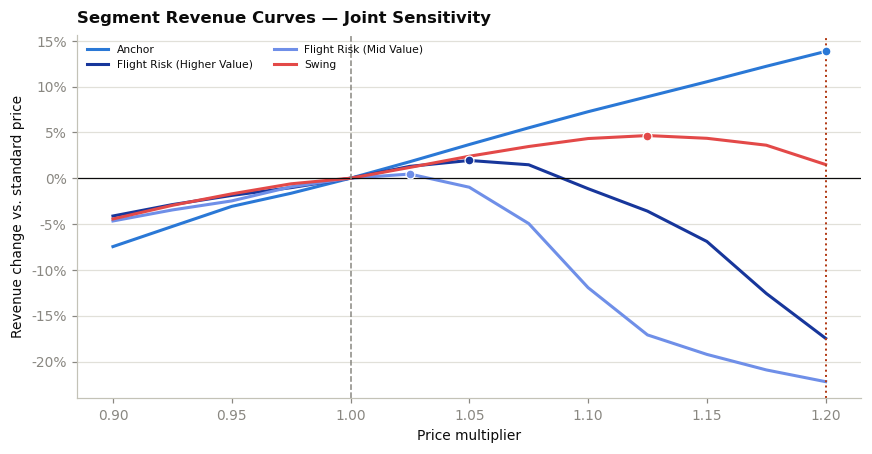

In [47]:
# Build Segment Revenue Curves
probability_grid = np.sort(
    prob_scen[
        'price_multiplier'
    ].round(4).unique()
)

revenue_grid = np.sort(
    rev_scen[
        'price_multiplier'
    ].round(4).unique()
)

assert np.array_equal(
    probability_grid,
    revenue_grid,
), 'probability and revenue grids do not match'

GRID = revenue_grid

required_prices = np.array([
    1.00,
    RECOMMENDED_PRICE,
    1.20,
])

assert all(
    np.isclose(
        GRID,
        price,
    ).any()
    for price in required_prices
), 'required segment-comparison prices are unavailable'

# Display anchors below read RECOMMENDED_PRICE dynamically (no longer
# hardcoded to 1.15), so this guard is now a no-op sanity check rather than
# a blocker: it just confirms the recommended price is on the evaluated grid.
assert np.isclose(GRID, RECOMMENDED_PRICE).any(), (
    'recommended price is not on the evaluated grid'
)

forward_trip_ids = (
    set(
        prob_scen[
            'trip_id'
        ].unique()
    )
    & set(
        rev_scen[
            'trip_id'
        ].unique()
    )
)

active_segments = seg.loc[
    ~seg['segment']
    .str.startswith(
        'Dormant',
        na=False,
    ),
    [
        'account_id',
        'segment',
    ],
]

trip_segment_map = (
    trips.loc[
        trips['trip_id'].isin(
            forward_trip_ids
        ),
        [
            'trip_id',
            'account_id',
        ],
    ]
    .merge(
        active_segments,
        on='account_id',
        how='inner',
        validate='many_to_one',
    )
    .dropna(subset=['segment'])
)

assert trip_segment_map[
    'trip_id'
].is_unique, 'duplicate trip IDs in the segment map'

probability_rows = (
    prob_scen.loc[
        prob_scen[
            'response_scenario'
        ].eq('stronger')
    ]
    .assign(
        price_multiplier=lambda frame:
            frame[
                'price_multiplier'
            ].round(4)
    )
    .merge(
        trip_segment_map[[
            'trip_id',
            'account_id',
            'segment',
        ]],
        on='trip_id',
        how='inner',
        validate='many_to_one',
    )
)

revenue_rows = (
    rev_scen.loc[
        rev_scen[
            'depth_scenario'
        ].eq('stronger')
    ]
    .assign(
        price_multiplier=lambda frame:
            frame[
                'price_multiplier'
            ].round(4)
    )
)

trip_price_results = probability_rows.merge(
    revenue_rows,
    on=[
        'trip_id',
        'price_multiplier',
    ],
    how='inner',
    validate='one_to_one',
)

trip_price_results['expected_revenue'] = (
    trip_price_results['p_null']
    * trip_price_results['rev_null']
    + trip_price_results['p_partial']
    * trip_price_results['rev_partial']
    + trip_price_results['p_full']
    * trip_price_results['rev_full']
)

assert np.isfinite(
    trip_price_results[
        'expected_revenue'
    ]
).all(), 'non-finite segment revenue'

assert (
    trip_price_results[
        'expected_revenue'
    ] >= 0
).all(), 'negative segment revenue'

seg_curve = (
    trip_price_results
    .groupby([
        'segment',
        'price_multiplier',
    ])[
        'expected_revenue'
    ]
    .sum()
    .reset_index(name='revenue')
)

piv = (
    seg_curve
    .pivot(
        index='price_multiplier',
        columns='segment',
        values='revenue',
    )
    .sort_index()
)

rel = (
    piv
    / piv.loc[1.0]
    - 1
)

port = piv.sum(axis=1)

stage3_joint = (
    sim_sweep.loc[
        sim_sweep[
            'case'
        ].eq('joint sensitivity')
    ]
    .set_index('price_multiplier')
    .sort_index()
)

stage3_median = (
    stage3_joint['median']
    .reindex(port.index)
)

assert stage3_median.notna().all(), (
    'Stage 03 simulation does not cover the '
    'segment-revenue grid'
)

selected_price_rows = []

for price in required_prices:
    selected_price_rows.append({
        'Price Multiplier': price,
        'Deterministic Revenue':
            port.loc[price],
        'Stage 03 Simulation Median':
            stage3_median.loc[price],
        'Deterministic Level Offset': (
            port.loc[price]
            / stage3_median.loc[price]
            - 1
        ),
    })

portfolio_comparison = pd.DataFrame(
    selected_price_rows
)

display(
    portfolio_comparison.style
    .hide(axis='index')
    .format({
        'Price Multiplier': '{:.2f}',
        'Deterministic Revenue': '{:,.0f}',
        'Stage 03 Simulation Median': '{:,.0f}',
        'Deterministic Level Offset': '{:+.1%}',
    })
    .bar(
        subset=['Deterministic Level Offset'],
        color='rgba(42, 120, 214, 0.55)',
        vmin=0,
        vmax=max(
            portfolio_comparison[
                'Deterministic Level Offset'
            ].max()
            * 1.10,
            0.01,
        ),
    )
    .set_caption(
        'Deterministic and Simulated Portfolio Revenue (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

deterministic_best_price = float(
    port.idxmax()
)

simulation_best_price = float(
    stage3_median.idxmax()
)

shape_summary = pd.DataFrame({
    'Track': [
        'Deterministic segment decomposition',
        'Stage 03 simulation median',
    ],
    'Best Evaluated Price': [
        deterministic_best_price,
        simulation_best_price,
    ],
    'Includes Occurrence Thinning': [
        'No',
        'Yes',
    ],
    'Includes Macro Variation': [
        'No',
        'Yes',
    ],
})

display(
    shape_summary.style
    .hide(axis='index')
    .format({
        'Best Evaluated Price': '{:.3f}',
    })
    .set_caption('Portfolio Price-Shape Reconciliation')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset=['Best Evaluated Price'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

best = pd.DataFrame({
    'best price': piv.idxmax(),
    'gain at best': (
        piv.max()
        - piv.loc[1.0]
    ),
    'gain at recommended': (
        piv.loc[RECOMMENDED_PRICE]
        - piv.loc[1.0]
    ),
    'gain at 1.20': (
        piv.loc[1.20]
        - piv.loc[1.0]
    ),
    'revenue share': (
        piv.loc[1.0]
        / piv.loc[1.0].sum()
    ),
})

segment_recommendations = (
    best
    .rename_axis('Segment')
    .reset_index()
    .rename(columns={
        'best price': 'Best Evaluated Price',
        'gain at best': 'Gain at Best Price',
        'gain at recommended': 'Gain at Recommended',
        'gain at 1.20': 'Gain at 1.20',
        'revenue share': 'Revenue Share',
    })
    .sort_values(
        'Revenue Share',
        ascending=False,
    )
)

maximum_gain = max(
    segment_recommendations[[
        'Gain at Best Price',
        'Gain at Recommended',
        'Gain at 1.20',
    ]]
    .abs()
    .to_numpy()
    .max(),
    1,
)

display(
    segment_recommendations.style
    .hide(axis='index')
    .format({
        'Best Evaluated Price': '{:.3f}',
        'Gain at Best Price': '{:+,.0f}',
        'Gain at Recommended': '{:+,.0f}',
        'Gain at 1.20': '{:+,.0f}',
        'Revenue Share': '{:.1%}',
    })
    .bar(
        subset=['Gain at Best Price'],
        align='mid',
        color=[
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin=-maximum_gain,
        vmax=maximum_gain,
    )
    .bar(
        subset=['Revenue Share'],
        color='rgba(42, 120, 214, 0.45)',
        vmin=0,
        vmax=0.50,
    )
    .set_caption(
        'Highest-Revenue Evaluated Price by Segment (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

key_relative_change = (
    rel.loc[
        required_prices
    ]
    .rename_axis(
        'Price Multiplier'
    )
    .reset_index()
)

display(
    key_relative_change.style
    .hide(axis='index')
    .format({
        'Price Multiplier': '{:.2f}',
        **{
            segment: '{:+.1%}'
            for segment in piv.columns
        },
    })
    .set_caption(
        'Segment Revenue Change vs. Standard Price'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

segment_colors = {
    segment: PALETTE[
        i % len(PALETTE)
    ]
    for i, segment
    in enumerate(piv.columns)
}

fig, ax = plt.subplots(
    figsize=(8, 4.2),
)

for segment in piv.columns:
    color = segment_colors[segment]

    ax.plot(
        rel.index,
        rel[segment],
        linewidth=2,
        color=color,
        label=segment.split(':')[0],
    )

    segment_best_price = float(
        piv[segment].idxmax()
    )

    ax.scatter(
        segment_best_price,
        rel.loc[
            segment_best_price,
            segment,
        ],
        color=color,
        edgecolor=SURFACE,
        linewidth=0.8,
        s=34,
        zorder=3,
    )

ax.axhline(
    0,
    color=INK,
    linewidth=0.8,
)

ax.axvline(
    1.0,
    color=MUTED,
    linestyle='--',
    linewidth=1,
)

ax.axvline(
    RECOMMENDED_PRICE,
    color='#b23c17',
    linestyle=':',
    linewidth=1.3,
)

ax.set(
    xlabel='Price multiplier',
    ylabel='Revenue change vs. standard price',
)

ax.set_title(
    'Segment Revenue Curves — Joint Sensitivity',
    loc='left',
    fontweight='bold',
    pad=8,
)

ax.yaxis.set_major_formatter(
    lambda value, position: f'{value:.0%}'
)

ax.grid(
    axis='y',
    color=GRIDLINE,
    linewidth=0.8,
)

ax.legend(
    frameon=False,
    fontsize=7,
    ncol=2,
)

plt.tight_layout()
plt.show()


In [48]:
# Build Segment Purchaser Curves
# A roaming-pass purchaser is an account with at least one forward-year trip
# receiving partial or full paid coverage (not a wireless-subscription measure —
# the study does not estimate wireless-account churn). Per account, per price:
#
#   P(at least one purchase) = 1 - prod(P(null coverage) over that account's
#                                        forward trips)
#
# summed across accounts in a segment for the expected purchaser count. This
# assumes conditional independence of an account's trip-purchase events — no
# account-level dependence is modeled here. Same grain and response scenario
# ('stronger' = joint sensitivity, unconditioned on macro scenario) as the
# segment revenue curve above, so the two are directly comparable — this is a
# deterministic expected-value decomposition, not a simulation, so (like
# segment revenue) it carries no interval.
account_null_product = (
    probability_rows
    .groupby([
        'account_id',
        'segment',
        'price_multiplier',
    ])['p_null']
    .prod()
    .reset_index(name='p_null_product')
)

account_null_product['p_purchase'] = (
    1 - account_null_product['p_null_product']
)

assert account_null_product['p_purchase'].between(0, 1).all(), (
    'account purchase probability outside [0, 1]'
)

seg_purchasers = (
    account_null_product
    .groupby([
        'segment',
        'price_multiplier',
    ])['p_purchase']
    .sum()
    .reset_index(name='purchasers')
)

assert np.isfinite(
    seg_purchasers['purchasers']
).all(), 'non-finite segment purchasers'

assert (
    seg_purchasers['purchasers'] >= 0
).all(), 'negative segment purchasers'

segment_account_counts = (
    active_segments
    .groupby('segment')['account_id']
    .nunique()
    .rename('segment_accounts')
)

purchaser_sanity = seg_purchasers.merge(
    segment_account_counts,
    on='segment',
    how='left',
)

assert (
    purchaser_sanity['purchasers']
    <= purchaser_sanity['segment_accounts'] + 1e-6
).all(), 'expected purchasers exceed segment account count'

purchaser_piv = (
    seg_purchasers
    .pivot(
        index='price_multiplier',
        columns='segment',
        values='purchasers',
    )
    .sort_index()
)

purchaser_rel = (
    purchaser_piv
    / purchaser_piv.loc[1.0]
    - 1
)

purchaser_key_change = (
    purchaser_piv
    .loc[required_prices]
    .rename_axis('Price Multiplier')
    .reset_index()
)

display(
    purchaser_key_change.style
    .hide(axis='index')
    .format({
        'Price Multiplier': '{:.2f}',
        **{
            segment: '{:,.0f}'
            for segment in purchaser_piv.columns
        },
    })
    .set_caption(
        'Expected Segment Purchasers at Key Prices'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

purchaser_pct_change = (
    purchaser_rel
    .loc[required_prices]
    .rename_axis('Price Multiplier')
    .reset_index()
)

display(
    purchaser_pct_change.style
    .hide(axis='index')
    .format({
        'Price Multiplier': '{:.2f}',
        **{
            segment: '{:+.1%}'
            for segment in purchaser_piv.columns
        },
    })
    .set_caption(
        'Segment Purchaser Change vs. Standard Price'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Price Multiplier,"Anchor: High Value, Low Sensitivity",Flight Risk (Higher Value): Discontinue Coverage,Flight Risk (Mid Value): Discontinue Coverage,Swing: Marginal Price Response
1.00,"7,900","1,708",519,"9,896"
1.20,"7,811","1,344",394,"9,169"
1.20,"7,811","1,344",394,"9,169"


Price Multiplier,"Anchor: High Value, Low Sensitivity",Flight Risk (Higher Value): Discontinue Coverage,Flight Risk (Mid Value): Discontinue Coverage,Swing: Marginal Price Response
1.00,+0.0%,+0.0%,+0.0%,+0.0%
1.20,-1.1%,-21.3%,-24.1%,-7.3%
1.20,-1.1%,-21.3%,-24.1%,-7.3%


<hr>
<div>
<h2>5 · Uniform Pricing Versus a Segment-Specific Upper Bound</h2>
<p style="border-left: 3px solid #b23c17; padding-left: 0.8em; color: #4A4A4A;"><strong>Note:</strong> This section’s revenue decomposition is deliberately computed under the joint stronger-response sensitivity throughout (see its own design notes below), independent of Section 5’s headline recommendation. Its “Gain at Recommended” column and reference line read RECOMMENDED_PRICE dynamically, so they correctly track the as-fitted recommendation (currently 1.20) even though the curve itself is the more conservative joint-sensitivity case.</p>
<p><strong>Purpose:</strong> Tests whether giving each segment its own highest-revenue grid price adds material modeled revenue beyond a single uniform price.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">Two pricing strategies are compared:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><strong>Uniform.</strong> every account receives the same price from the evaluated grid.</li>
<li><strong>Segment-Specific.</strong> each segment receives its own highest-revenue grid price.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The segment-specific strategy is a deterministic gross-revenue upper bound. It assumes every account is assigned to the correct segment, that segment responses are stable, and that separate prices carry no billing, communication, legal, or fairness cost. It does not model competitive reactions or customer responses to differentiated pricing.</li>
<li style="margin-bottom: 0.7em;">This section does not set the company-wide recommendation. Notebook 03 establishes the recommended common price (1.20). This section only asks whether segment-specific pricing adds material modeled value on top of it.</li>
<li style="margin-bottom: 0.7em;">Both strategies are evaluated over the four active segments. Dormant is excluded for the same reason it is set aside throughout Sections 4-5 (it purchases at no price), and its modeled gain is under a few thousand dollars at any price, so its exclusion does not change the comparison.</li>
<li style="margin-bottom: 0.7em;">The comparison is a single deterministic pass on the same per-trip scenario tables used in Section 4. There is no Monte Carlo split, so the figures are point estimates without a simulation-noise band; they are read as a gross-revenue ceiling, not a significance test.</li>
<li style="margin-bottom: 0.7em;">The incremental value of segment-specific pricing is <code>segment-specific gain − uniform gain</code>, both measured against revenue at 1.00.</li>
<li style="margin-bottom: 0.7em;">Behavioral revenue exposure is derived from the segment-level curves rather than from <code>revenue per account × response_span</code>. A no-response counterfactual charges the recommended price while holding standard-price coverage probabilities fixed; the gap between that counterfactual and the modeled-response result is the revenue eroded by behavior.</li>
<li style="margin-bottom: 0.7em;">Two exposure measures are reported: per-account behavioral exposure (average erosion per account in the segment) and total behavioral exposure (aggregate erosion across the segment). They answer different questions: concentrated individual risk versus where the largest amount of portfolio revenue moves.</li>
<li style="margin-bottom: 0.7em;">Flight risk refers to modeled movement toward no roaming-pass coverage, not wireless churn.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>Deterministic comparison over the four active segments, joint stronger-response sensitivity:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Strategy</th>
<th style="text-align: left;">Modeled 12-month gain vs 1.00</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Uniform at the recommended price (1.20)</td>
<td style="text-align: left; vertical-align: top;">+&#36;131,473</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Uniform, best single grid price (1.15)</td>
<td style="text-align: left; vertical-align: top;">+&#36;157,577</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Segment-specific, each segment at its own best price</td>
<td style="text-align: left; vertical-align: top;">+&#36;237,859</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Gross value of segment-specific pricing</td>
<td style="text-align: left; vertical-align: top;">+&#36;80,282 (+50.9% of the best uniform gain)</td>
</tr>
</tbody>
</table></li>
<li>Under this joint-sensitivity decomposition the best single uniform price is 1.15. The study's recommended 1.20 is read from the as-fitted model; in this decomposition it gives up &#36;26,104 of deterministic gain relative to 1.15.</li>
<li>Segment-specific prices and gains (active segments; Dormant is set aside and adds no material selective gain):
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Segment</th>
<th style="text-align: left;">Highest grid price</th>
<th style="text-align: left;">Gain vs 1.00</th>
<th style="text-align: left;">Gain at the uniform 1.15</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Anchor: High Value, Low Sensitivity</td>
<td style="text-align: left; vertical-align: top;">1.20</td>
<td style="text-align: left; vertical-align: top;">+&#36;172,010</td>
<td style="text-align: left; vertical-align: top;">+&#36;130,863</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Swing: Marginal Price Response</td>
<td style="text-align: left; vertical-align: top;">1.125</td>
<td style="text-align: left; vertical-align: top;">+&#36;60,403</td>
<td style="text-align: left; vertical-align: top;">+&#36;56,500</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight Risk (Higher Value): Discontinue Coverage</td>
<td style="text-align: left; vertical-align: top;">1.05</td>
<td style="text-align: left; vertical-align: top;">+&#36;5,180</td>
<td style="text-align: left; vertical-align: top;">−&#36;18,481</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight Risk (Mid Value): Discontinue Coverage</td>
<td style="text-align: left; vertical-align: top;">1.025</td>
<td style="text-align: left; vertical-align: top;">+&#36;266</td>
<td style="text-align: left; vertical-align: top;">−&#36;11,304</td>
</tr>
</tbody>
</table></li>
<li>About 51% of the &#36;80,282 gap (+&#36;41,148) comes from moving Anchor to the 1.20 grid edge, which the grid cannot confirm is a true optimum. Another +&#36;35,231 comes from <em>not</em> raising price on the two Flight-risk segments: at the uniform 1.15 they lose a combined &#36;29,785, and at their own near-standard prices (1.05 and 1.025) they roughly break even. The remaining +&#36;3,904 is Swing sitting at 1.125 rather than 1.15.</li>
<li>Behavioral revenue exposure at the recommended 1.20 (revenue given up because customers respond):
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Segment</th>
<th style="text-align: left;">Per-account exposure</th>
<th style="text-align: left;">Total exposure</th>
<th style="text-align: left;">Share of total exposure</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Swing: Marginal Price Response</td>
<td style="text-align: left; vertical-align: top;">&#36;19.73</td>
<td style="text-align: left; vertical-align: top;">&#36;212,714</td>
<td style="text-align: left; vertical-align: top;">53.6%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight Risk (Higher Value): Discontinue Coverage</td>
<td style="text-align: left; vertical-align: top;">&#36;50.41</td>
<td style="text-align: left; vertical-align: top;">&#36;94,411</td>
<td style="text-align: left; vertical-align: top;">23.8%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Anchor: High Value, Low Sensitivity</td>
<td style="text-align: left; vertical-align: top;">&#36;8.17</td>
<td style="text-align: left; vertical-align: top;">&#36;66,178</td>
<td style="text-align: left; vertical-align: top;">16.7%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Flight Risk (Mid Value): Discontinue Coverage</td>
<td style="text-align: left; vertical-align: top;">&#36;40.52</td>
<td style="text-align: left; vertical-align: top;">&#36;23,338</td>
<td style="text-align: left; vertical-align: top;">5.9%</td>
</tr>
</tbody>
</table></li>
<li>Unlike a cap-bound result, the model now shows a material deterministic gap (~51%) between selective and uniform pricing, driven by segment heterogeneity in the price response. It is still a gross-revenue ceiling: no simulation-noise band, no implementation or fairness cost, and correct segment assignment assumed.</li>
<li>The defensible reading: the modeled results suggest that substantially higher prices could reduce roaming-pass revenue in the two Flight-risk segments, and that the best uniform increase (1.15) leaves roughly &#36;80,000 per year of modeled gross revenue relative to a segment-specific policy whose operating cost this study does not estimate.</li>
<li>Segmentation therefore informs the pricing question here, not only retention and monitoring, but whether &#36;80,000 a year justifies charging different customers different prices for one product depends on costs outside this study.</li>
</ol>
</div>


In [49]:
# Compare Uniform and Selective Pricing
segment_lookup = (
    summary
    .set_index('segment')
)

active_segments = [
    segment
    for segment in piv.columns
    if not bool(
        segment_lookup.loc[
            segment,
            'is_dormant',
        ]
    )
]

active_revenue = piv[
    active_segments
]

active_portfolio = (
    active_revenue.sum(axis=1)
)

uniform_best_price = float(
    active_portfolio.idxmax()
)

uniform_gain = float(
    active_portfolio.max()
    - active_portfolio.loc[1.0]
)

uniform_gain_at_rec = float(
    active_portfolio.loc[RECOMMENDED_PRICE]
    - active_portfolio.loc[1.0]
)

selective_gain = float(
    (
        active_revenue.max()
        - active_revenue.loc[1.0]
    ).sum()
)

segmentation_value = (
    selective_gain
    - uniform_gain
)

segmentation_uplift = (
    segmentation_value
    / max(
        uniform_gain,
        1e-9,
    )
)

# Study assumption (reviewer-visible convention, not tied to an approved cost figure):
# a segmentation uplift below 2% of the uniform gain is treated as not decision-relevant
# once unmodeled billing, communication, and fairness costs are considered.
materiality_threshold = 0.02

if segmentation_uplift < materiality_threshold:
    policy_assessment = (
        'A uniform increase captures substantially all modeled '
        'gross-revenue opportunity; segmentation is more useful '
        'for identifying retention priorities'
    )
else:
    policy_assessment = (
        'Segment-specific pricing produces greater modeled gross '
        'revenue, before any implementation or fairness cost'
    )

policy_comparison = pd.DataFrame({
    'Policy': [
        'Uniform — best evaluated price',
        'Uniform — recommended price',
        'Selective — segment-specific prices',
    ],
    'Price': [
        f'{uniform_best_price:.3f}×',
        f'{RECOMMENDED_PRICE:.3f}×',
        'Varies by segment',
    ],
    'Gain vs. Standard': [
        uniform_gain,
        uniform_gain_at_rec,
        selective_gain,
    ],
    'Increment vs. Uniform Best': [
        0.0,
        (
            uniform_gain_at_rec
            - uniform_gain
        ),
        segmentation_value,
    ],
})

maximum_policy_difference = max(
    policy_comparison[
        'Increment vs. Uniform Best'
    ]
    .abs()
    .max(),
    1,
)

display(
    policy_comparison.style
    .hide(axis='index')
    .format({
        'Gain vs. Standard': '{:+,.0f}',
        'Increment vs. Uniform Best': '{:+,.0f}',
    })
    .bar(
        subset=['Increment vs. Uniform Best'],
        align='mid',
        color=[
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin=-maximum_policy_difference,
        vmax=maximum_policy_difference,
    )
    .set_caption(
        'Uniform and Selective Pricing Comparison (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

segmentation_summary = pd.DataFrame({
    'Value of Segmentation': [
        segmentation_value
    ],
    'Increase vs. Uniform Gain': [
        segmentation_uplift
    ],
    'Materiality Threshold': [
        materiality_threshold
    ],
    'Assessment': [
        policy_assessment
    ],
})

display(
    segmentation_summary.style
    .hide(axis='index')
    .format({
        'Value of Segmentation': '{:+,.0f}',
        'Increase vs. Uniform Gain': '{:+.1%}',
        'Materiality Threshold': '{:.0%}',
    })
    .set_caption('Incremental Value of Selective Pricing')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset=[
            'Value of Segmentation',
            'Increase vs. Uniform Gain',
        ],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

segment_optima = pd.DataFrame({
    'Segment': active_segments,
    'Best Evaluated Price': [
        active_revenue[
            segment
        ].idxmax()
        for segment in active_segments
    ],
    'Gain at Best Price': [
        (
            active_revenue[
                segment
            ].max()
            - active_revenue.loc[
                1.0,
                segment,
            ]
        )
        for segment in active_segments
    ],
    'Gain at Recommended': [
        (
            active_revenue.loc[
                RECOMMENDED_PRICE,
                segment,
            ]
            - active_revenue.loc[
                1.0,
                segment,
            ]
        )
        for segment in active_segments
    ],
})

maximum_segment_gain = max(
    segment_optima[[
        'Gain at Best Price',
        'Gain at Recommended',
    ]]
    .abs()
    .to_numpy()
    .max(),
    1,
)

display(
    segment_optima.style
    .hide(axis='index')
    .format({
        'Best Evaluated Price': '{:.3f}',
        'Gain at Best Price': '{:+,.0f}',
        'Gain at Recommended': '{:+,.0f}',
    })
    .bar(
        subset=['Gain at Best Price'],
        align='mid',
        color=[
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin=-maximum_segment_gain,
        vmax=maximum_segment_gain,
    )
    .set_caption(
        'Highest-Revenue Evaluated Price by Active Segment (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

standard_probabilities = (
    probability_rows.loc[
        np.isclose(
            probability_rows[
                'price_multiplier'
            ],
            1.0,
        ),
        [
            'trip_id',
            'segment',
            'p_null',
            'p_partial',
            'p_full',
        ],
    ]
)

revenue_at_rec = (
    revenue_rows.loc[
        np.isclose(
            revenue_rows[
                'price_multiplier'
            ],
            RECOMMENDED_PRICE,
        ),
        [
            'trip_id',
            'rev_null',
            'rev_partial',
            'rev_full',
        ],
    ]
)

no_response_results = (
    standard_probabilities
    .merge(
        revenue_at_rec,
        on='trip_id',
        how='inner',
        validate='one_to_one',
    )
)

no_response_results['revenue_without_response'] = (
    no_response_results['p_null']
    * no_response_results['rev_null']
    + no_response_results['p_partial']
    * no_response_results['rev_partial']
    + no_response_results['p_full']
    * no_response_results['rev_full']
)

revenue_without_response = (
    no_response_results
    .groupby('segment')[
        'revenue_without_response'
    ]
    .sum()
)

behavioral_exposure = (
    revenue_without_response
    - active_revenue.loc[RECOMMENDED_PRICE]
).reindex(active_segments)

account_count = segment_lookup.loc[
    active_segments,
    'accounts',
]

exposure = pd.DataFrame({
    'Total Exposure': behavioral_exposure,
    'Per-Account Exposure': (
        behavioral_exposure
        / account_count
    ),
    'Share of Total Exposure': (
        behavioral_exposure
        / behavioral_exposure.sum()
    ),
}).sort_values(
    'Total Exposure',
    ascending=False,
)

exposure_display = (
    exposure
    .rename_axis('Segment')
    .reset_index()
)

display(
    exposure_display.style
    .hide(axis='index')
    .format({
        'Total Exposure': '{:,.0f}',
        'Per-Account Exposure': '{:,.2f}',
        'Share of Total Exposure': '{:.1%}',
    })
    .bar(
        subset=['Total Exposure'],
        color='rgba(235, 104, 52, 0.45)',
        vmin=0,
        vmax=max(
            exposure[
                'Total Exposure'
            ].max()
            * 1.10,
            1,
        ),
    )
    .bar(
        subset=['Share of Total Exposure'],
        color='rgba(42, 120, 214, 0.55)',
        vmin=0,
        vmax=1,
    )
    .set_caption(
        'Behavioral Revenue Exposure at the Recommended Price (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Policy,Price,Gain vs. Standard,Increment vs. Uniform Best
Uniform — best evaluated price,1.150×,"+157,577",+0
Uniform — recommended price,1.200×,"+131,473","-26,104"
Selective — segment-specific prices,Varies by segment,"+237,859","+80,282"


Value of Segmentation,Increase vs. Uniform Gain,Materiality Threshold,Assessment
"+80,282",+50.9%,2%,"Segment-specific pricing produces greater modeled gross revenue, before any implementation or fairness cost"


Segment,Best Evaluated Price,Gain at Best Price,Gain at Recommended
"Anchor: High Value, Low Sensitivity",1.200,"+172,010","+172,010"
Flight Risk (Higher Value): Discontinue Coverage,1.050,"+5,180","-46,775"
Flight Risk (Mid Value): Discontinue Coverage,1.025,+266,"-13,054"
Swing: Marginal Price Response,1.125,"+60,403","+19,292"


Segment,Total Exposure,Per-Account Exposure,Share of Total Exposure
Swing: Marginal Price Response,"212,714",19.73,53.6%
Flight Risk (Higher Value): Discontinue Coverage,"94,411",50.41,23.8%
"Anchor: High Value, Low Sensitivity","66,178",8.17,16.7%
Flight Risk (Mid Value): Discontinue Coverage,"23,338",40.52,5.9%


<hr>
<div>
<h2>6 · Power BI Data Handoff</h2>
<p><strong>Purpose:</strong> Publishes a versioned set of normalized tables and the relationships to build from them, so downstream exploration in Power BI does not require rerunning the modeling notebooks.</p>
<p><strong>Portfolio Scope:</strong> This notebook creates the data tables and documents the model to build in Power BI; it does not create or publish a <code>.pbix</code> report, and it does not run column-level, foreign-key, or read-back validation on the exports. A report or standalone scenario page built from these outputs should display the same simulation-run identifier and documented assumptions.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The handoff supports exploration of precomputed results.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Users can select one of the 13 evaluated prices.</li>
<li>Users can compare the base model with the joint stronger-response sensitivity (portfolio table).</li>
<li>Users can compare contraction, base, and expansion conditions.</li>
<li>Users can filter segment-level results and review modeled revenue exposure.</li>
<li>Users cannot generate unevaluated prices or new model scenarios without rerunning the notebooks.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Five dimension or reference tables:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Table</th>
<th style="text-align: left;">Grain</th>
<th style="text-align: left;">Purpose</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_price</code></td>
<td style="text-align: left; vertical-align: top;">One row per evaluated price</td>
<td style="text-align: left; vertical-align: top;">Price, percentage change, first- and additional-line price, observed and cap flags, recommended flag</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_segment</code></td>
<td style="text-align: left; vertical-align: top;">One row per final segment</td>
<td style="text-align: left; vertical-align: top;">Versioned segment name, description, profile summary, and reporting order</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_scenario</code></td>
<td style="text-align: left; vertical-align: top;">One row per macroeconomic condition</td>
<td style="text-align: left; vertical-align: top;">Contraction, base, and expansion shifts</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_model_case</code></td>
<td style="text-align: left; vertical-align: top;">One row per model-sensitivity case</td>
<td style="text-align: left; vertical-align: top;">The as-fitted model and the joint stronger-response sensitivity, with their scales</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_assumption</code></td>
<td style="text-align: left; vertical-align: top;">One row per named assumption</td>
<td style="text-align: left; vertical-align: top;">Model, simulation, and run identifiers</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;">Three fact tables:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Table</th>
<th style="text-align: left;">Grain</th>
<th style="text-align: left;">Measures</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>fact_portfolio_simulation</code></td>
<td style="text-align: left; vertical-align: top;">One row per price and model case (13 × 2)</td>
<td style="text-align: left; vertical-align: top;">p5, median, p95, price-change percentage, observed-price-point flag, run id; plus the single 1.15-vs-1.00 negative-paired frequency on the recommended row only</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>fact_macro_scenario</code></td>
<td style="text-align: left; vertical-align: top;">One row per macroeconomic condition and price (3 × 3)</td>
<td style="text-align: left; vertical-align: top;">Absolute revenue percentiles, and the paired 1.15-vs-1.00 difference carried on the 1.15 row</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>fact_segment_revenue</code></td>
<td style="text-align: left; vertical-align: top;">One row per active segment and price (4 × 13), joint sensitivity; Dormant is excluded</td>
<td style="text-align: left; vertical-align: top;">Deterministic expected segment revenue, revenue at the standard price, and the difference from it (not a simulated distribution)</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><code>bridge_account_segment</code> has one row per forward-year synthetic account, mapping it to exactly one segment with stable account and segment identifiers plus a few account-level response measures for portfolio demonstrations.</li>
<li style="margin-bottom: 0.7em;">Relationships to set in Power BI (printed by the export cell):
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">From</th>
<th style="text-align: left;">To</th>
<th style="text-align: left;">Key</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_price[price_multiplier]</code></td>
<td style="text-align: left; vertical-align: top;"><code>fact_portfolio_simulation[price_multiplier]</code></td>
<td style="text-align: left; vertical-align: top;"><code>price_multiplier</code></td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_price[price_multiplier]</code></td>
<td style="text-align: left; vertical-align: top;"><code>fact_segment_revenue[price_multiplier]</code></td>
<td style="text-align: left; vertical-align: top;"><code>price_multiplier</code></td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_price[price_multiplier]</code></td>
<td style="text-align: left; vertical-align: top;"><code>fact_macro_scenario[price]</code></td>
<td style="text-align: left; vertical-align: top;">price</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_segment[segment_id]</code></td>
<td style="text-align: left; vertical-align: top;"><code>fact_segment_revenue[segment_id]</code></td>
<td style="text-align: left; vertical-align: top;"><code>segment_id</code></td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_segment[segment_id]</code></td>
<td style="text-align: left; vertical-align: top;"><code>bridge_account_segment[segment_id]</code></td>
<td style="text-align: left; vertical-align: top;"><code>segment_id</code></td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_scenario[scenario]</code></td>
<td style="text-align: left; vertical-align: top;"><code>fact_macro_scenario[scenario]</code></td>
<td style="text-align: left; vertical-align: top;"><code>scenario</code></td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_model_case[model_case]</code></td>
<td style="text-align: left; vertical-align: top;"><code>fact_portfolio_simulation[case]</code></td>
<td style="text-align: left; vertical-align: top;"><code>case</code></td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><code>dim_assumption</code> is a disconnected reference table. It displays the assumptions for the selected simulation run and does not filter revenue facts. Simulation outcomes such as the observed frequency of a negative paired difference travel in the fact tables, not the assumptions.</li>
<li style="margin-bottom: 0.7em;">Every exported table carries a <code>run_id</code> column with the same value. A report must not combine tables from different runs.</li>
<li style="margin-bottom: 0.7em;"><code>dim_price</code> flags historically observed prices and prices inside the study’s +20% cap.</li>
<li style="margin-bottom: 0.7em;">The model reduces the need for Power BI transformations but does not eliminate DAX: the revenue percentiles are precomputed, and measures are still used for formatting, selection, and display logic. The <code>Downside (p5)</code> measure returns the 5th-percentile revenue level at the selected price, not an incremental downside versus 1.00. The report should not interpolate new results between exported prices.</li>
<li style="margin-bottom: 0.7em;">Segment filtering applies only to <code>fact_segment_revenue</code>. Portfolio and macroeconomic distributions are not segment-specific. Without the <code>dim_model_case</code> relationship above, a portfolio measure will sum the as-fitted and joint-sensitivity rows together.</li>
<li style="margin-bottom: 0.7em;">Files are written to a project-relative <code>data/powerbi</code> directory.</li>
<li style="margin-bottom: 0.7em;"><code>save_tables</code> writes the nine tables and reports their row and column counts, and the notebook prints the relationships to set. Column-level, foreign-key, and read-back validation are not performed in code.</li>
<li style="margin-bottom: 0.7em;">All account identifiers and results are synthetic. The handoff contains no client-identifying information or proprietary production output.</li>
</ol>
<p><strong>Observations:</strong></p>
<p style="margin-bottom: 0;">The handoff contains nine tables:</p>
<table style="margin-top: 0; width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Table</th>
<th style="text-align: left;">Rows</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_price.parquet</code></td>
<td style="text-align: left; vertical-align: top;">13</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_segment.parquet</code></td>
<td style="text-align: left; vertical-align: top;">5</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_scenario.parquet</code></td>
<td style="text-align: left; vertical-align: top;">3</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_model_case.parquet</code></td>
<td style="text-align: left; vertical-align: top;">2</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>dim_assumption.parquet</code></td>
<td style="text-align: left; vertical-align: top;">7</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>fact_portfolio_simulation.parquet</code></td>
<td style="text-align: left; vertical-align: top;">26</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>fact_macro_scenario.parquet</code></td>
<td style="text-align: left; vertical-align: top;">9</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>fact_segment_revenue.parquet</code></td>
<td style="text-align: left; vertical-align: top;">52</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>bridge_account_segment.parquet</code></td>
<td style="text-align: left; vertical-align: top;">22,328</td>
</tr>
</tbody>
</table>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li>All price facts use <code>price_multiplier</code> (or <code>price</code>) as the shared price key.</li>
<li>The scenario and model-case dimensions let the same labels and order be reused across visuals.</li>
<li>Segment-level results are separated from portfolio-level uncertainty so a segment filter does not imply detail the simulation did not produce.</li>
<li><code>dim_assumption</code> records how the displayed results were generated without mixing inputs with outcomes.</li>
<li>The simulation-run identifier stamped on every table is <code>sim-crn4242-sweep400-macro300-paired800</code>.</li>
</ol>
</div>


In [50]:
# Export Power BI Tables
OBS_PRICES = [0.90, 0.95, 1.00, 1.10, 1.20]
REC_PRICE = RECOMMENDED_PRICE   # derived in 'Load Segmentation Inputs' from the §03 sweep

scenarios = load('simulation_scenarios')
assumptions = load('simulation_assumptions')
probability_curve_export = load('probability_curve')
sensitivity_grid_export = load('sensitivity_grid')
assumption_values = assumptions.set_index('assumption')['value']
RUN_ID = str(assumption_values.get('simulation run id', 'unknown'))

# Dimensions
dim_price = pd.DataFrame({
    'price_multiplier': np.round(np.sort(np.asarray(GRID, dtype=float)), 4)
})
dim_price = dim_price.drop_duplicates().reset_index(drop=True)
dim_price['price_change_pct'] = ((dim_price['price_multiplier'] - 1) * 100).round(2)
dim_price['first_line_price'] = (10.0 * dim_price['price_multiplier']).round(2)
dim_price['addl_line_price'] = (5.0 * dim_price['price_multiplier']).round(2)
dim_price['observed'] = dim_price['price_multiplier'].isin(OBS_PRICES)
dim_price['within_cap'] = dim_price['price_multiplier'].le(1.20 + 1e-9)
dim_price['is_recommended'] = np.isclose(
    dim_price['price_multiplier'], REC_PRICE
)

segment_source = summary.rename_axis('cluster').reset_index()
segment_columns = [
    'cluster', 'segment', 'is_dormant', 'accounts', 'acct_share',
    'rev_share', 'rev_per_acct', 'business', 'trips_per_acct',
    'baseline_risk', 'response_span', 'reduce_vs_quit',
]
missing_segment_columns = sorted(set(segment_columns) - set(segment_source.columns))
assert not missing_segment_columns, (
    f'missing segment fields: {missing_segment_columns}'
)

dim_segment = (
    segment_source[segment_columns]
    .rename(columns={'cluster': 'segment_id'})
    .copy()
)
dim_segment['headline'] = (
    dim_segment['segment'].str.partition(':')[0].str.strip()
)
dim_segment['description'] = (
    dim_segment['segment'].str.partition(':')[2].str.strip()
    .replace('', pd.NA)
)
dim_segment['sort_order'] = (
    dim_segment['rev_share']
    .rank(method='first', ascending=False)
    .astype(int)
)

dim_scenario = (
    scenarios[['scenario', 'macro_shift']]
    .drop_duplicates()
    .sort_values('macro_shift')
    .reset_index(drop=True)
)

dim_model_case = pd.DataFrame({
    'model_case': ['as fitted', 'joint sensitivity'],
    'response_scale': [
        1.0,
        float(assumption_values.get(
            'response scale (joint sensitivity)', RESPONSE_RATIO
        )),
    ],
    'depth_scale': [
        1.0,
        float(assumption_values.get(
            'depth scale (joint sensitivity)', DEPTH_BIAS
        )),
    ],
    'note': [
        'Fitted state and magnitude models; recommendation case',
        'Stronger response and depth; disclosed robustness check, not the recommendation case',
    ],
})

dim_assumption = assumptions.copy()

# Facts and bridge
name_to_id = dim_segment.set_index('segment')['segment_id']

segment_base = (
    seg_curve.loc[
        np.isclose(seg_curve['price_multiplier'], 1.0),
        ['segment', 'revenue'],
    ]
    .rename(columns={'revenue': 'revenue_at_base'})
)

fact_segment_revenue = (
    seg_curve
    .assign(
        price_multiplier=lambda d: d['price_multiplier'].round(4),
        segment_id=lambda d: d['segment'].map(name_to_id),
    )
    .merge(segment_base, on='segment', how='left', validate='many_to_one')
)
fact_segment_revenue['revenue_vs_base'] = (
    fact_segment_revenue['revenue']
    - fact_segment_revenue['revenue_at_base']
)
fact_segment_revenue['revenue_change_pct'] = (
    fact_segment_revenue['revenue']
    / fact_segment_revenue['revenue_at_base']
    - 1
)

# Expected purchasers (deterministic decomposition, see 'Build Segment Purchaser
# Curves' above) — same grain as revenue, joined on (segment, price_multiplier).
purchasers_base = (
    seg_purchasers.loc[
        np.isclose(seg_purchasers['price_multiplier'], 1.0),
        ['segment', 'purchasers'],
    ]
    .rename(columns={'purchasers': 'purchasers_at_base'})
)

fact_segment_revenue = (
    fact_segment_revenue
    .assign(price_multiplier=lambda d: d['price_multiplier'].round(4))
    .merge(
        seg_purchasers.assign(
            price_multiplier=lambda d: d['price_multiplier'].round(4)
        ),
        on=['segment', 'price_multiplier'],
        how='left',
        validate='many_to_one',
    )
    .merge(purchasers_base, on='segment', how='left', validate='many_to_one')
)
fact_segment_revenue['purchasers_vs_base'] = (
    fact_segment_revenue['purchasers']
    - fact_segment_revenue['purchasers_at_base']
)
fact_segment_revenue['purchasers_change_pct'] = (
    fact_segment_revenue['purchasers']
    / fact_segment_revenue['purchasers_at_base']
    - 1
)

fact_portfolio_simulation = sim_sweep.copy()
fact_portfolio_simulation['price_multiplier'] = (
    fact_portfolio_simulation['price_multiplier'].round(4)
)

fact_macro_scenario = scenarios.copy()
fact_macro_scenario['price'] = fact_macro_scenario['price'].round(4)

fact_probability_curve = probability_curve_export.copy()
fact_probability_curve['price_multiplier'] = (
    fact_probability_curve['price_multiplier'].round(4)
)

fact_sensitivity_grid = sensitivity_grid_export.copy()
fact_sensitivity_grid['price_multiplier'] = (
    fact_sensitivity_grid['price_multiplier'].round(4)
)
fact_sensitivity_grid['response_scale'] = (
    fact_sensitivity_grid['response_scale'].round(6)
)
fact_sensitivity_grid['depth_scale'] = (
    fact_sensitivity_grid['depth_scale'].round(6)
)

bridge_account_segment = (
    seg[
        [
            'account_id', 'cluster', 'segment', 'revenue',
            'baseline_risk', 'response_span',
        ]
    ]
    .rename(columns={'cluster': 'segment_id'})
    .copy()
)

tables = {
    'dim_price': dim_price,
    'dim_segment': dim_segment,
    'dim_scenario': dim_scenario,
    'dim_model_case': dim_model_case,
    'dim_assumption': dim_assumption,
    'fact_portfolio_simulation': fact_portfolio_simulation,
    'fact_macro_scenario': fact_macro_scenario,
    'fact_segment_revenue': fact_segment_revenue,
    'fact_probability_curve': fact_probability_curve,
    'fact_sensitivity_grid': fact_sensitivity_grid,
    'bridge_account_segment': bridge_account_segment,
}

for table in tables.values():
    table['run_id'] = RUN_ID

# Model-integrity checks
assert RUN_ID != 'unknown', 'simulation run id is missing'
assert dim_price['price_multiplier'].is_unique, 'duplicate prices in dim_price'
assert dim_segment['segment_id'].is_unique, 'duplicate segment IDs'
assert dim_segment['segment'].is_unique, 'duplicate segment names'
assert dim_scenario['scenario'].is_unique, 'duplicate scenario names'
assert dim_model_case['model_case'].is_unique, 'duplicate model cases'
assert dim_price['is_recommended'].sum() == 1, (
    f'recommended price x{REC_PRICE:.2f} is not uniquely represented'
)

price_keys = set(dim_price['price_multiplier'])
segment_keys = set(dim_segment['segment_id'])
scenario_keys = set(dim_scenario['scenario'])
case_keys = set(dim_model_case['model_case'])

assert set(fact_portfolio_simulation['price_multiplier']) <= price_keys
assert set(fact_segment_revenue['price_multiplier']) <= price_keys
assert set(fact_macro_scenario['price']) <= price_keys
assert set(fact_segment_revenue['segment_id']) <= segment_keys
assert set(bridge_account_segment['segment_id']) <= segment_keys
assert set(fact_macro_scenario['scenario']) <= scenario_keys
assert set(fact_portfolio_simulation['case']) <= case_keys
assert set(fact_probability_curve['price_multiplier']) <= price_keys
assert fact_probability_curve['response_scale'].nunique() == 3, (
    'expected exactly 3 response_scale grid points in fact_probability_curve'
)
assert set(fact_sensitivity_grid['price_multiplier']) <= price_keys

assert fact_segment_revenue['segment_id'].notna().all()
assert fact_segment_revenue['revenue_at_base'].notna().all()
assert fact_segment_revenue['purchasers'].notna().all(), (
    'missing segment purchaser figures'
)
assert fact_segment_revenue['purchasers_at_base'].notna().all(), (
    'missing base-price segment purchaser figures'
)
assert (fact_segment_revenue['purchasers'] >= 0).all(), (
    'negative segment purchasers in export'
)
assert np.allclose(
    fact_probability_curve[['p_null', 'p_partial', 'p_full']].sum(axis=1),
    1.0,
    atol=1e-6,
), 'exported coverage-state probabilities do not sum to one'
assert (
    fact_probability_curve[['p_null', 'p_partial', 'p_full']].to_numpy() >= 0
).all(), 'negative coverage-state probability in export'

assert (fact_sensitivity_grid['p5'] <= fact_sensitivity_grid['median'] + 1e-6).all()
assert (fact_sensitivity_grid['median'] <= fact_sensitivity_grid['p95'] + 1e-6).all()
assert (fact_sensitivity_grid['purchasers_p5'] <= fact_sensitivity_grid['purchasers_median'] + 1e-6).all()
assert (fact_sensitivity_grid['purchasers_median'] <= fact_sensitivity_grid['purchasers_p95'] + 1e-6).all()
assert (fact_sensitivity_grid[['p5', 'purchasers_p5']].to_numpy() >= 0).all(), (
    'negative value in fact_sensitivity_grid'
)
assert fact_sensitivity_grid['response_scale'].nunique() == 3, (
    'expected exactly 3 response_scale grid points in fact_sensitivity_grid'
)
assert fact_sensitivity_grid['depth_scale'].nunique() == 3, (
    'expected exactly 3 depth_scale grid points in fact_sensitivity_grid'
)

assert all(
    table['run_id'].eq(RUN_ID).all()
    for table in tables.values()
)

BI = DATA.parent / 'powerbi'
written = save_tables(tables, dest=BI, with_cols=True)

manifest = pd.DataFrame({
    'table': list(tables),
    'rows': [len(table) for table in tables.values()],
    'columns': [table.shape[1] for table in tables.values()],
}).set_index('table')

display(
    manifest.style
    .set_caption('Power BI Export Manifest')
    .format({'rows': '{:,.0f}', 'columns': '{:,.0f}'})
    .set_table_styles(TABLE_STYLES)
)

relationships = pd.DataFrame([
    ('dim_price', 'price_multiplier',
     'fact_portfolio_simulation', 'price_multiplier'),
    ('dim_price', 'price_multiplier',
     'fact_segment_revenue', 'price_multiplier'),
    ('dim_price', 'price_multiplier',
     'fact_macro_scenario', 'price'),
    ('dim_segment', 'segment_id',
     'fact_segment_revenue', 'segment_id'),
    ('dim_segment', 'segment_id',
     'bridge_account_segment', 'segment_id'),
    ('dim_scenario', 'scenario',
     'fact_macro_scenario', 'scenario'),
    ('dim_model_case', 'model_case',
     'fact_portfolio_simulation', 'case'),
    ('dim_price', 'price_multiplier',
     'fact_probability_curve', 'price_multiplier'),
    ('dim_price', 'price_multiplier',
     'fact_sensitivity_grid', 'price_multiplier'),
], columns=['dimension', 'dimension_key', 'fact', 'fact_key'])

display(
    relationships.style
    .set_caption('Power BI Relationships — One-to-Many, Single Direction')
    .hide(axis='index')
    .set_table_styles(TABLE_STYLES)
)

print(f'Export complete: {len(tables)} tables written to {BI}')
print(f'Run ID: {RUN_ID}')


,rows,columns
table,,
dim_price,13,8
dim_segment,5,16
dim_scenario,3,3
dim_model_case,2,5
dim_assumption,7,4
fact_portfolio_simulation,26,16
fact_macro_scenario,9,21
fact_segment_revenue,52,12
fact_probability_curve,39,6


dimension,dimension_key,fact,fact_key
dim_price,price_multiplier,fact_portfolio_simulation,price_multiplier
dim_price,price_multiplier,fact_segment_revenue,price_multiplier
dim_price,price_multiplier,fact_macro_scenario,price
dim_segment,segment_id,fact_segment_revenue,segment_id
dim_segment,segment_id,bridge_account_segment,segment_id
dim_scenario,scenario,fact_macro_scenario,scenario
dim_model_case,model_case,fact_portfolio_simulation,case
dim_price,price_multiplier,fact_probability_curve,price_multiplier
dim_price,price_multiplier,fact_sensitivity_grid,price_multiplier


Export complete: 11 tables written to data/powerbi
Run ID: sim-crn4242-sweep400-macro300-paired800


In [51]:
# Define Power BI Measures
measures = pd.DataFrame([
    {
        'measure': 'Net Revenue',
        'dax': 'SUM(fact_portfolio_simulation[median])',
        'format_string': '$#,0;($#,0);$0',
        'display_folder': 'Revenue',
        'note': 'Median simulated revenue; show with the uncertainty band.',
    },
    {
        'measure': 'Revenue vs Base',
        'dax': (
            '[Net Revenue] - '
            'CALCULATE([Net Revenue], REMOVEFILTERS(dim_price), '
            'dim_price[price_multiplier] = 1.0)'
        ),
        'format_string': '$#,0;($#,0);$0',
        'display_folder': 'Revenue',
        'note': 'Change from x1.00 within the current model-case context.',
    },
    {
        'measure': 'Revenue vs Base %',
        'dax': (
            'VAR BaseRevenue = '
            'CALCULATE([Net Revenue], REMOVEFILTERS(dim_price), '
            'dim_price[price_multiplier] = 1.0) '
            'RETURN DIVIDE([Net Revenue] - BaseRevenue, BaseRevenue)'
        ),
        'format_string': '0.0%;(0.0%);0.0%',
        'display_folder': 'Revenue',
        'note': 'Percentage change from x1.00.',
    },
    {
        'measure': 'Downside (p5)',
        'dax': 'SUM(fact_portfolio_simulation[p5])',
        'format_string': '$#,0;($#,0);$0',
        'display_folder': 'Uncertainty',
        'note': '5th-percentile revenue level, not incremental downside.',
    },
    {
        'measure': 'Upside (p95)',
        'dax': 'SUM(fact_portfolio_simulation[p95])',
        'format_string': '$#,0;($#,0);$0',
        'display_folder': 'Uncertainty',
        'note': '95th-percentile revenue level.',
    },
    {
        'measure': 'Risk Band',
        'dax': '[Upside (p95)] - [Downside (p5)]',
        'format_string': '$#,0;($#,0);$0',
        'display_folder': 'Uncertainty',
        'note': 'Width of the p5–p95 simulation interval.',
    },
    {
        'measure': 'Segment Revenue',
        'dax': 'SUM(fact_segment_revenue[revenue])',
        'format_string': '$#,0;($#,0);$0',
        'display_folder': 'Segments',
        'note': 'Deterministic segment revenue in the current price context.',
    },
    {
        'measure': 'Segment Revenue Share',
        'dax': (
            'DIVIDE([Segment Revenue], '
            'CALCULATE([Segment Revenue], REMOVEFILTERS(dim_segment)))'
        ),
        'format_string': '0.0%',
        'display_folder': 'Segments',
        'note': 'Share of portfolio revenue at the selected price.',
    },
])

required_columns = {
    'measure', 'dax', 'format_string', 'display_folder', 'note'
}
assert required_columns <= set(measures.columns)
assert measures['measure'].is_unique, 'duplicate Power BI measure names'
assert measures['dax'].str.strip().ne('').all(), 'one or more measures lack DAX'

measure_catalog = (
    measures[['measure', 'display_folder', 'note']]
    .rename(columns={
        'measure': 'Measure',
        'display_folder': 'Folder',
        'note': 'Purpose',
    })
)

display(
    measure_catalog.style
    .hide(axis='index')
    .set_caption('Recommended Power BI Measures')
    .set_table_styles(TABLE_STYLES + [
        {'selector': 'table', 'props': [
            ('width', '100%'),
            ('table-layout', 'fixed'),
        ]},
        {'selector': 'th', 'props': [
            ('text-align', 'left'),
            ('white-space', 'nowrap'),
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'left'),
            ('vertical-align', 'top'),
            ('white-space', 'normal'),
            ('overflow-wrap', 'break-word'),
        ]},
        {'selector': 'th.col0, td.col0', 'props': [('width', '24%')]},
        {'selector': 'th.col1, td.col1', 'props': [('width', '18%')]},
        {'selector': 'th.col2, td.col2', 'props': [('width', '58%')]},
    ])
)

path = BI / 'measures.csv'
measures.to_csv(path, index=False)

print(f'Exported {len(measures)} measure definitions to {path.name}')


Measure,Folder,Purpose
Net Revenue,Revenue,Median simulated revenue; show with the uncertainty band.
Revenue vs Base,Revenue,Change from x1.00 within the current model-case context.
Revenue vs Base %,Revenue,Percentage change from x1.00.
Downside (p5),Uncertainty,"5th-percentile revenue level, not incremental downside."
Upside (p95),Uncertainty,95th-percentile revenue level.
Risk Band,Uncertainty,Width of the p5–p95 simulation interval.
Segment Revenue,Segments,Deterministic segment revenue in the current price context.
Segment Revenue Share,Segments,Share of portfolio revenue at the selected price.


Exported 8 measure definitions to measures.csv


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h3>The Complete Study Chain</h3>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Section</th>
<th style="text-align: left;">Role in the study</th>
<th style="text-align: left;">Question it answers</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">00 · Data Generation and Validation</td>
<td style="text-align: left; vertical-align: top;">Creates and validates the synthetic historical dataset</td>
<td style="text-align: left; vertical-align: top;">What information would the study require, and does the synthetic dataset satisfy those requirements?</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">01 · The State Model</td>
<td style="text-align: left; vertical-align: top;">Estimates coverage-state probabilities across the evaluated price grid</td>
<td style="text-align: left; vertical-align: top;">What is the probability that a trip receives null, partial, or full roaming coverage at each candidate price?</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">02 · The Magnitude Model</td>
<td style="text-align: left; vertical-align: top;">Estimates retained coverage within the partial state and translates each state into revenue</td>
<td style="text-align: left; vertical-align: top;">When partial coverage occurs, how much coverage is retained, and what revenue is associated with each state?</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">03 · The 12-Month Simulation</td>
<td style="text-align: left; vertical-align: top;">Combines trip volume, state probabilities, coverage magnitude, and shared uncertainty</td>
<td style="text-align: left; vertical-align: top;">What distribution of 12-month roaming-pass revenue results at each evaluated price and under each specified scenario?</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">04 · Segmentation, Profiling, and Handoff</td>
<td style="text-align: left; vertical-align: top;">Describes response-and-value groups and publishes the downstream reporting tables</td>
<td style="text-align: left; vertical-align: top;">How do modeled response and revenue exposure differ across account segments, and how can the results be explored?</td>
</tr>
</tbody>
</table>
<h3>Four Points to State Plainly When Presenting</h3>
<p><strong>1. The recommendation is a 20% increase, read directly from the as-fitted models.</strong> On the 13-point price grid, modeled roaming-pass revenue is still rising at the +20% cap under the as-fitted models, so 1.20 is reported as the best evaluated price within the study's permitted range, not a proven unconstrained optimum. Scaled against independent U.S. international air-travel data and a disclosed 30% assumed carrier market share (Section 5.1), that price change is worth roughly &#36;104 million against the &#36;100 million company-wide target.</p>
<p><strong>2. A disclosed robustness check, not the recommendation basis, tests a more pessimistic scenario.</strong> Two diagnostics motivate it: the State Model’s regional holdout produced a stronger response than the base model predicted for the withheld region, and the Magnitude Model’s synthetic-label check found deeper reductions among truly reducing trips than among all trips reconstructed as partial coverage. Under that joint stronger-response sensitivity, modeled revenue instead peaks at 1.15. That scenario is a sensitivity test, not an unbiased correction, statistical bound, or alternative estimate of truth, and it is not incorporated into the price selection, but even under it, a price increase remains clearly favorable to the standard price; the disagreement with the as-fitted case is about how far to raise price, not about whether to.</p>
<p><strong>3. Segment responses differ enough that a single price leaves modeled revenue on the table.</strong> The deterministic segment decomposition gives each of the four priced segments its own highest-revenue grid price: that ceiling is about &#36;80,000 a year (roughly 51%) above the best uniform increase (1.15). Most of the gap comes from <em>not</em> raising price on the two price-sensitive Flight-risk segments, which lose revenue at 1.15, and from pushing the low-sensitivity Anchor segment to the cap. This is a gross-revenue ceiling with no simulation-noise band and no estimate of the billing, communication, or fairness cost of charging different customers different prices, so it is not a recommendation to do so. Segmentation also shows where behavioral response and revenue exposure are concentrated and supports monitoring, product, and retention hypotheses.</p>
<p><strong>4. The conclusion is intentionally narrow.</strong> This is a portfolio reconstruction using complete synthetic data. The recommendation applies to modeled roaming-pass revenue within the evaluated price range. The study does not include wireless churn, customer-lifetime effects, competitor reactions, implementation costs, customer-welfare effects, or the effectiveness of proposed segment treatments. The exported tables contain precomputed scenarios for exploration; they are not a live forecasting or pricing system.</p>
</div>
